<a href="https://colab.research.google.com/github/SahanWijayaraja/Frame-AI/blob/main/FrameAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Cell 1 - YOLOv8n export

!pip install ultralytics -q
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.export(format='tflite', imgsz=320, int8=True)
print("yolov8n_int8.tflite ready - ~3MB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 84, 2100) (6.2 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0

In [7]:


import urllib.request
url = "https://storage.googleapis.com/download.tensorflow.org/models/tflite/gpu/deeplabv3_257_mv_gpu.tflite"
urllib.request.urlretrieve(url, "deeplabv3.tflite")
import os
print(f"DeepLabV3: {os.path.getsize('deeplabv3.tflite')//1024} KB")

DeepLabV3: 2714 KB


In [8]:
 #MiDaS Small download

import urllib.request
url = "https://github.com/isl-org/MiDaS/releases/download/v2_1/model_opt.tflite"
urllib.request.urlretrieve(url, "midas_small.tflite")
import os
print(f"MiDaS Small: {os.path.getsize('midas_small.tflite')//1024} KB")

MiDaS Small: 64783 KB


In [9]:
# Install required libraries
!pip install tensorflow -q
!pip install keras -q
!pip install Pillow numpy -q
print("Done — all libraries installed")

Done — all libraries installed


In [10]:
import urllib.request, os

# Download the aesthetic model weights (.hdf5 file)
url = "https://github.com/idealo/image-quality-assessment/raw/master/models/MobileNet/weights_mobilenet_aesthetic_0.07.hdf5"
urllib.request.urlretrieve(url, "weights_mobilenet_aesthetic.hdf5")

size_mb = os.path.getsize("weights_mobilenet_aesthetic.hdf5") / 1024 / 1024
print(f"Downloaded: weights_mobilenet_aesthetic.hdf5 ({size_mb:.1f} MB)")

Downloaded: weights_mobilenet_aesthetic.hdf5 (12.6 MB)


In [11]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.models import Model

def build_nima_model():
    # Base MobileNet — same architecture idealo used
    base = MobileNet(
        input_shape=(224, 224, 3),
        alpha=1,
        include_top=False,
        pooling='avg',
        weights=None
    )
    # Add NIMA head — outputs 10 scores (rating distribution 1-10)
    x = Dropout(0.75)(base.output)
    x = Dense(10, activation='softmax')(x)
    model = Model(base.input, x)
    return model

model = build_nima_model()
model.load_weights("weights_mobilenet_aesthetic.hdf5")
print("Model loaded successfully!")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")

Model loaded successfully!
Input shape:  (None, 224, 224, 3)
Output shape: (None, 10)


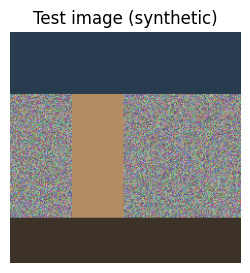

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
Raw distribution: [      0.014       0.117       0.143       0.249       0.267       0.124       0.053       0.028       0.005           0]
Aesthetic score:  43.9 / 100
Result: Average quality


In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Create a synthetic test image — no URL, no download, no blocking
# This simulates a real photo for testing the model
np.random.seed(42)
test_array = np.random.randint(80, 200, (224, 224, 3), dtype=np.uint8)

# Add a fake "subject" — a brighter rectangle in the centre-left area
# This mimics a person standing roughly at the rule-of-thirds position
test_array[60:180, 60:110] = [180, 140, 100]   # warm skin-tone blob

# Add a darker background
test_array[0:60, :] = [40, 60, 80]             # sky — dark blue
test_array[180:, :] = [60, 50, 40]             # ground — dark brown

img = Image.fromarray(test_array)

# Show the image so you can see what the model is scoring
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title("Test image (synthetic)")
plt.axis('off')
plt.show()

# Preprocess for NIMA — same as before
img_array = np.array(img, dtype=np.float32) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# Run inference
scores = model.predict(img_batch)[0]

# Convert 10-bucket distribution to a 0-100 mean score
mean_score = float(np.sum(scores * np.arange(1, 11))) / 10 * 100

print(f"Raw distribution: {np.round(scores, 3)}")
print(f"Aesthetic score:  {mean_score:.1f} / 100")

if mean_score >= 60:
    print("Result: Good aesthetic quality")
elif mean_score >= 40:
    print("Result: Average quality")
else:
    print("Result: Poor aesthetic quality")

Upload any photo from your phone — JPG or PNG


Saving IMG_20260102_155247 (4).jpg to IMG_20260102_155247 (4).jpg


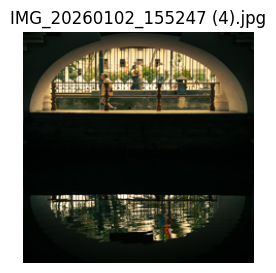

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
File: IMG_20260102_155247 (4).jpg
Aesthetic score: 34.3 / 100
Result: Needs improvement
---


In [13]:
from google.colab import files
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("Upload any photo from your phone — JPG or PNG")
uploaded = files.upload()   # opens file picker in Colab

for filename, data in uploaded.items():
    import io
    img = Image.open(io.BytesIO(data)).convert("RGB")
    img_resized = img.resize((224, 224))

    # Show the uploaded photo
    plt.figure(figsize=(3, 3))
    plt.imshow(img_resized)
    plt.title(filename)
    plt.axis('off')
    plt.show()

    # Preprocess + score
    img_array = np.array(img_resized, dtype=np.float32) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    scores = model.predict(img_batch)[0]
    mean_score = float(np.sum(scores * np.arange(1, 11))) / 10 * 100

    print(f"File: {filename}")
    print(f"Aesthetic score: {mean_score:.1f} / 100")
    if mean_score >= 60:
        print("Result: Good aesthetic quality ✓")
    elif mean_score >= 40:
        print("Result: Average quality")
    else:
        print("Result: Needs improvement")
    print("---")

In [14]:
import os

# Convert Keras model → TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimise for mobile — makes it smaller and faster
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save the file
output_path = "nima_mobilenet.tflite"
with open(output_path, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(output_path) / 1024 / 1024
print(f"Saved: {output_path} ({size_mb:.1f} MB)")
print("Ready to use in your Flutter app!")

Saved artifact at '/tmp/tmpp_7obqb6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139350179406928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350176598736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350176600080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350176599120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350179404432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350176597968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350102933328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350176599888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350102931792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139350102932944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1393501794088

In [15]:
# Load and run the TFLite model to confirm it works
interpreter = tf.lite.Interpreter(model_path="nima_mobilenet.tflite")
interpreter.allocate_tensors()

inp  = interpreter.get_input_details()
outp = interpreter.get_output_details()
print(f"TFLite input  shape: {inp[0]['shape']}")
print(f"TFLite output shape: {outp[0]['shape']}")

# Run inference with the same test image
interpreter.set_tensor(inp[0]['index'], img_batch)
interpreter.invoke()
tflite_scores = interpreter.get_tensor(outp[0]['index'])[0]

tflite_score = float(np.sum(tflite_scores * np.arange(1, 11))) / 10 * 100
print(f"TFLite score: {tflite_score:.1f} / 100")
print("TFLite model verified and working!")

TFLite input  shape: [  1 224 224   3]
TFLite output shape: [ 1 10]
TFLite score: 34.0 / 100
TFLite model verified and working!


In [16]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
import os # Import the os module

dest_dir = '/content/drive/MyDrive/FrameAI_models/' # Define the destination directory
os.makedirs(dest_dir, exist_ok=True) # Create the directory if it doesn't exist

dest = os.path.join(dest_dir, 'nima_mobilenet.tflite') # Construct the full destination path
shutil.copy("nima_mobilenet.tflite", dest)
print(f"Saved to Google Drive: {dest}")

Mounted at /content/drive
Saved to Google Drive: /content/drive/MyDrive/FrameAI_models/nima_mobilenet.tflite


Loading DeepLabV3 model...
Input  shape: [  1 257 257   3]
Output shape: [  1 257 257  21]
Model loaded!

Creating test scene...
Test scene created.

Running segmentation...
Raw output shape: (1, 257, 257, 21)
Segmentation map shape: (257, 257)
Unique class IDs found: [0]

Analysing framing...
Detected subject class: [0] background

Border analysis:
  TOP   : class [0] background    ← same as subject
  BOTTOM: class [0] background    ← same as subject
  LEFT  : class [0] background    ← same as subject
  RIGHT : class [0] background    ← same as subject


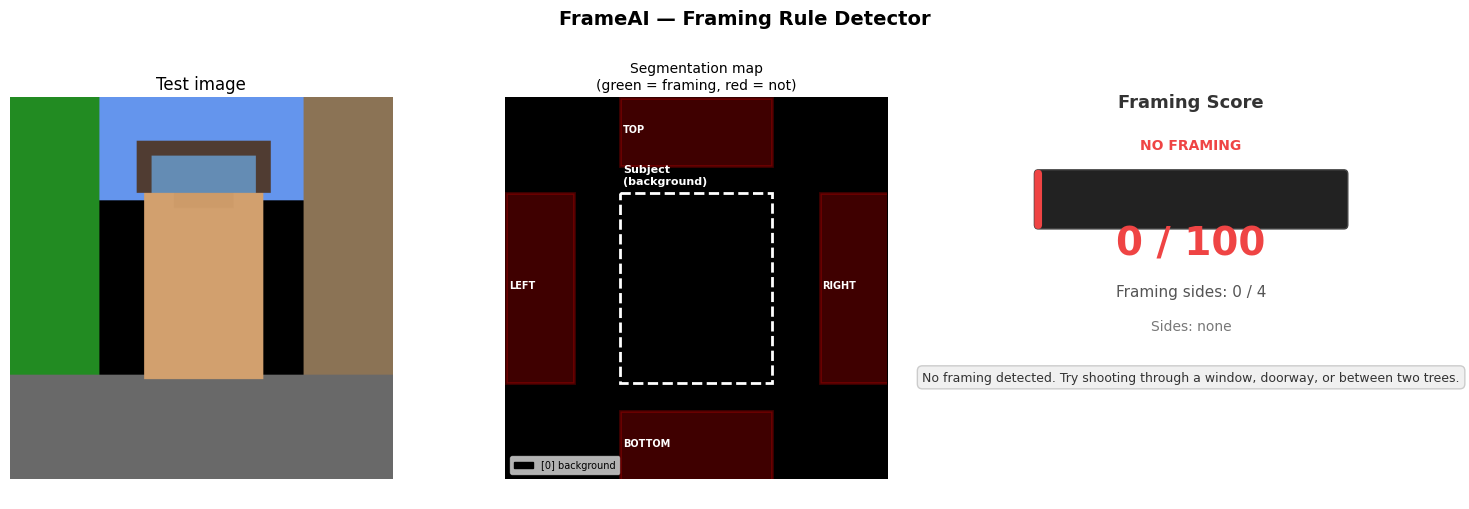


FRAMING ANALYSIS RESULT
Subject detected : [0] background
Framing sides    : 0 / 4  (none)
Framing score    : 0 / 100
Verdict          : NO FRAMING
Tip              : No framing detected. Try shooting through a window, doorway, or between two trees.


In [17]:
# ============================================================
# FrameAI — Framing Rule Detector using DeepLabV3
# Tests if subject is surrounded by different objects on 3+ sides
# ============================================================

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import io

# ── STEP 1: Load the DeepLabV3 TFLite model ──────────────────
print("Loading DeepLabV3 model...")
interpreter = tf.lite.Interpreter(model_path="deeplabv3.tflite")
interpreter.allocate_tensors()

inp_details  = interpreter.get_input_details()
out_details  = interpreter.get_output_details()

# DeepLabV3 expects 257x257 input
MODEL_SIZE = 257

print(f"Input  shape: {inp_details[0]['shape']}")
print(f"Output shape: {out_details[0]['shape']}")
print("Model loaded!\n")

# ── STEP 2: Create a test image ───────────────────────────────
# We build a synthetic scene so no URL download is needed:
#   - Blue sky at the top
#   - Person (warm tones) standing in the centre
#   - Green tree/plant on the left
#   - Brown wall/building on the right
#   - Grey ground at the bottom
# This mimics a "framed subject" scene

print("Creating test scene...")
canvas = np.zeros((257, 257, 3), dtype=np.uint8)

# Sky — top strip
canvas[0:70,   :,   :] = [100, 149, 237]   # cornflower blue

# Left tree/plant — left strip
canvas[0:257,  0:60, :] = [34,  139,  34]  # forest green

# Right wall/building — right strip
canvas[0:257, 197:257, :] = [139, 115, 85] # warm brown

# Ground — bottom strip
canvas[187:257, :,   :] = [105, 105, 105]  # grey ground

# Person/subject — centre rectangle (warm skin + clothes)
canvas[60:190, 90:170, :] = [210, 160, 110] # warm body
canvas[40:75,  110:150, :] = [205, 155, 105] # head

# Add doorway suggestion — darker arch above the person
canvas[30:65,  85:175, :] = [80, 60, 50]    # dark doorframe
canvas[40:65,  95:165, :] = [100, 140, 180] # opening (sky visible through)

test_image_pil = Image.fromarray(canvas)
print("Test scene created.\n")

# ── STEP 3: Run DeepLabV3 segmentation ───────────────────────
print("Running segmentation...")

# Resize to model input size and normalise to float32 0.0–1.0
img_resized = test_image_pil.resize((MODEL_SIZE, MODEL_SIZE))
img_array   = np.array(img_resized, dtype=np.float32) / 255.0
img_batch   = np.expand_dims(img_array, axis=0)

# Feed into the model
interpreter.set_tensor(inp_details[0]['index'], img_batch)
interpreter.invoke()

# Get the raw output — shape is (1, 257, 257, 21) or (1, 257, 257)
raw_output = interpreter.get_tensor(out_details[0]['index'])
print(f"Raw output shape: {raw_output.shape}")

# Handle both output formats:
# Format A: (1, H, W, 21) → pick class with highest score per pixel
# Format B: (1, H, W)     → already class index per pixel
if len(raw_output.shape) == 4:
    seg_map = np.argmax(raw_output[0], axis=-1)  # shape: (257, 257)
else:
    seg_map = raw_output[0].astype(np.int32)      # shape: (257, 257)

print(f"Segmentation map shape: {seg_map.shape}")
unique_classes = np.unique(seg_map)
print(f"Unique class IDs found: {unique_classes}\n")

# ── STEP 4: Colour the segmentation map ──────────────────────
# DeepLabV3 has 21 classes (PASCAL VOC dataset)
CLASS_NAMES = [
    'background', 'aeroplane', 'bicycle',  'bird',   'boat',
    'bottle',     'bus',       'car',       'cat',    'chair',
    'cow',        'diningtable','dog',      'horse',  'motorbike',
    'person',     'pottedplant','sheep',    'sofa',   'train',
    'tvmonitor'
]

# Distinct colour for each of the 21 classes
CLASS_COLORS = np.array([
    [0,   0,   0  ], [128, 0,   0  ], [0,   128, 0  ], [128, 128, 0  ],
    [0,   0,   128], [128, 0,   128], [0,   128, 128], [128, 128, 128],
    [64,  0,   0  ], [192, 0,   0  ], [64,  128, 0  ], [192, 128, 0  ],
    [64,  0,   128], [192, 0,   128], [64,  128, 128], [192, 128, 128],
    [0,   64,  0  ], [128, 64,  0  ], [0,   192, 0  ], [128, 192, 0  ],
    [0,   64,  128]
], dtype=np.uint8)

# Paint every pixel with its class colour
coloured_map = CLASS_COLORS[seg_map % 21]

# ── STEP 5: Detect framing ────────────────────────────────────
print("Analysing framing...")

H, W = seg_map.shape

# Find the dominant class in the centre 40% of the image
# This is assumed to be the main subject
cx1, cx2 = int(W * 0.30), int(W * 0.70)
cy1, cy2 = int(H * 0.25), int(H * 0.75)
centre_region = seg_map[cy1:cy2, cx1:cx2]
subject_class = int(np.bincount(centre_region.flatten()).argmax())
subject_name  = CLASS_NAMES[subject_class] if subject_class < len(CLASS_NAMES) else f"class_{subject_class}"
print(f"Detected subject class: [{subject_class}] {subject_name}")

# Define 4 border strips — each is a thin band along one edge
STRIP = int(H * 0.18)   # 18% of image height/width for each strip
strips = {
    "TOP"   : seg_map[0:STRIP,        cx1:cx2     ],
    "BOTTOM": seg_map[H-STRIP:H,      cx1:cx2     ],
    "LEFT"  : seg_map[cy1:cy2,        0:STRIP     ],
    "RIGHT" : seg_map[cy1:cy2,        W-STRIP:W   ],
}

# A side "frames" the subject if its dominant class ≠ subject class
framing_sides   = []
non_framing_sides = []

print("\nBorder analysis:")
for side, region in strips.items():
    if region.size == 0:
        continue
    dominant = int(np.bincount(region.flatten()).argmax())
    dom_name  = CLASS_NAMES[dominant] if dominant < len(CLASS_NAMES) else f"class_{dominant}"
    is_framing = (dominant != subject_class)

    if is_framing:
        framing_sides.append(side)
        print(f"  {side:6s}: class [{dominant}] {dom_name:12s}  ← DIFFERENT → frames subject ✓")
    else:
        non_framing_sides.append(side)
        print(f"  {side:6s}: class [{dominant}] {dom_name:12s}  ← same as subject")

# ── STEP 6: Calculate framing score ──────────────────────────
sides_count = len(framing_sides)

# Score logic:
#   0 framing sides → 0
#   1 side          → 25  (weak, barely framed)
#   2 sides         → 55  (decent — two sides)
#   3 sides         → 80  (strong — classic frame within frame)
#   4 sides         → 98  (perfect — subject fully enclosed)
score_map = {0: 0, 1: 25, 2: 55, 3: 80, 4: 98}
framing_score = score_map[sides_count]

# ── STEP 7: Build tip message ─────────────────────────────────
if sides_count >= 3:
    tip = f"Excellent framing! Subject enclosed on {sides_count} sides ({', '.join(framing_sides)})"
    verdict = "STRONG FRAMING DETECTED"
elif sides_count == 2:
    missing = [s for s in ["TOP","BOTTOM","LEFT","RIGHT"] if s not in framing_sides]
    tip = f"Partial framing. Try adding an element on the {missing[0]} side too."
    verdict = "PARTIAL FRAMING"
elif sides_count == 1:
    tip = "Only one framing element found. Look for a doorway, arch, or tree to frame from more sides."
    verdict = "WEAK FRAMING"
else:
    tip = "No framing detected. Try shooting through a window, doorway, or between two trees."
    verdict = "NO FRAMING"

# ── STEP 8: Visualise everything ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 — Original test image
axes[0].imshow(test_image_pil)
axes[0].set_title("Test image", fontsize=12)
axes[0].axis('off')

# Panel 2 — Coloured segmentation map with bounding boxes
axes[1].imshow(coloured_map)

# Draw centre box (subject region)
rect_subj = mpatches.Rectangle(
    (cx1, cy1), cx2-cx1, cy2-cy1,
    linewidth=2, edgecolor='white', facecolor='none', linestyle='--'
)
axes[1].add_patch(rect_subj)
axes[1].text(cx1+2, cy1-6, f"Subject\n({subject_name})",
             color='white', fontsize=8, fontweight='bold')

# Draw framing strip boxes in green, non-framing in red
strip_coords = {
    "TOP"   : (cx1,   0,      cx2-cx1,  STRIP         ),
    "BOTTOM": (cx1,   H-STRIP,cx2-cx1,  STRIP         ),
    "LEFT"  : (0,     cy1,    STRIP,    cy2-cy1       ),
    "RIGHT" : (W-STRIP,cy1,   STRIP,    cy2-cy1       ),
}
for side, (x, y, w, h) in strip_coords.items():
    color = 'lime' if side in framing_sides else 'red'
    rect  = mpatches.Rectangle((x, y), w, h,
                linewidth=2, edgecolor=color, facecolor=color, alpha=0.25)
    axes[1].add_patch(rect)
    axes[1].text(x+2, y+h//2, side, color='white', fontsize=7, fontweight='bold')

axes[1].set_title("Segmentation map\n(green = framing, red = not)", fontsize=10)
axes[1].axis('off')

# Build legend for detected classes
legend_patches = []
for cls_id in unique_classes:
    if cls_id < len(CLASS_NAMES):
        color = CLASS_COLORS[cls_id % 21] / 255.0
        legend_patches.append(
            mpatches.Patch(color=color, label=f"[{cls_id}] {CLASS_NAMES[cls_id]}")
        )
if legend_patches:
    axes[1].legend(handles=legend_patches, loc='lower left',
                   fontsize=7, framealpha=0.7)

# Panel 3 — Score summary
axes[2].set_xlim(0, 10)
axes[2].set_ylim(0, 10)
axes[2].axis('off')

# Score bar background
bar_bg = mpatches.FancyBboxPatch((1, 6.5), 8, 1.2,
    boxstyle="round,pad=0.1", linewidth=1,
    edgecolor='#444', facecolor='#222')
axes[2].add_patch(bar_bg)

# Filled portion of score bar
bar_color = '#00D4AA' if framing_score >= 70 else \
            '#F59E0B' if framing_score >= 40 else '#EF4444'
bar_fill = mpatches.FancyBboxPatch((1, 6.5), 8 * framing_score / 100, 1.2,
    boxstyle="round,pad=0.1", linewidth=0,
    edgecolor='none', facecolor=bar_color)
axes[2].add_patch(bar_fill)

axes[2].text(5, 9.3, "Framing Score",   ha='center', fontsize=13, fontweight='bold', color='#333')
axes[2].text(5, 8.3, verdict,           ha='center', fontsize=10, color=bar_color, fontweight='bold')
axes[2].text(5, 5.8, f"{framing_score} / 100", ha='center', fontsize=28, fontweight='bold', color=bar_color)
axes[2].text(5, 4.8, f"Framing sides: {sides_count} / 4", ha='center', fontsize=11, color='#555')
axes[2].text(5, 4.0, f"Sides: {', '.join(framing_sides) if framing_sides else 'none'}",
             ha='center', fontsize=10, color='#777')
axes[2].text(5, 2.8, tip, ha='center', fontsize=9, color='#333',
             wrap=True, multialignment='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', edgecolor='#ccc'))

plt.suptitle("FrameAI — Framing Rule Detector", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── STEP 9: Final printed summary ────────────────────────────
print("\n" + "="*50)
print("FRAMING ANALYSIS RESULT")
print("="*50)
print(f"Subject detected : [{subject_class}] {subject_name}")
print(f"Framing sides    : {sides_count} / 4  ({', '.join(framing_sides) if framing_sides else 'none'})")
print(f"Framing score    : {framing_score} / 100")
print(f"Verdict          : {verdict}")
print(f"Tip              : {tip}")
print("="*50)

Upload a photo — try one with a doorway, window, or trees around the subject


Saving istockphoto-1304221332-612x612.jpg to istockphoto-1304221332-612x612.jpg

Analysing: istockphoto-1304221332-612x612.jpg


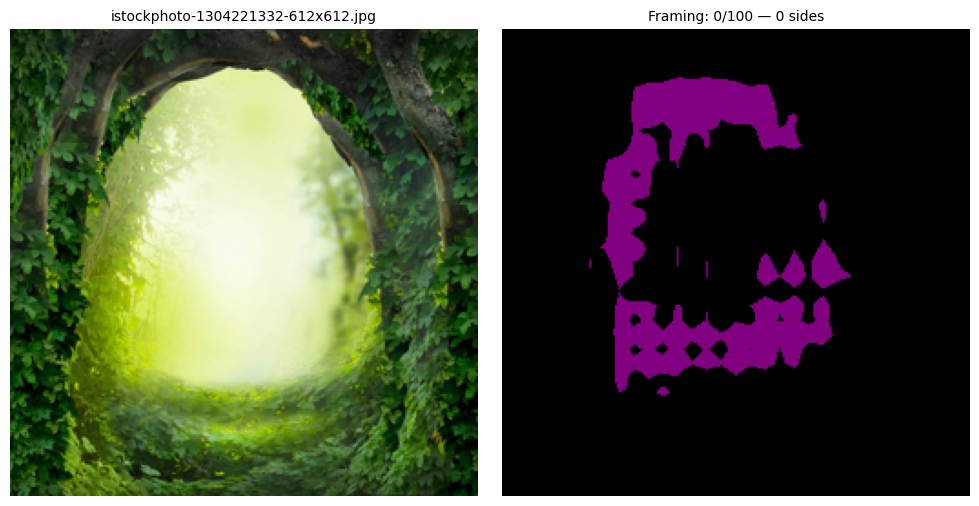

Subject  : background
Sides    : 0/4  (none)
Score    : 0 / 100


In [19]:
# ── Test framing on YOUR real photos ─────────────────────────
from google.colab import files
import io

print("Upload a photo — try one with a doorway, window, or trees around the subject")
uploaded = files.upload()

for filename, data in uploaded.items():
    print(f"\nAnalysing: {filename}")

    # Load and resize
    img = Image.open(io.BytesIO(data)).convert("RGB")
    img_resized = img.resize((MODEL_SIZE, MODEL_SIZE))
    img_array   = np.array(img_resized, dtype=np.float32) / 255.0
    img_batch   = np.expand_dims(img_array, axis=0)

    # Run segmentation
    interpreter.set_tensor(inp_details[0]['index'], img_batch)
    interpreter.invoke()
    raw_output = interpreter.get_tensor(out_details[0]['index'])

    if len(raw_output.shape) == 4:
        seg_map = np.argmax(raw_output[0], axis=-1)
    else:
        seg_map = raw_output[0].astype(np.int32)

    # Detect framing — same logic as above
    H, W = seg_map.shape
    cx1, cx2 = int(W*0.30), int(W*0.70)
    cy1, cy2 = int(H*0.25), int(H*0.75)
    STRIP = int(H*0.18)

    centre_region = seg_map[cy1:cy2, cx1:cx2]
    subject_class = int(np.bincount(centre_region.flatten()).argmax())
    subject_name  = CLASS_NAMES[subject_class] if subject_class < len(CLASS_NAMES) else f"class_{subject_class}"

    strips = {
        "TOP"   : seg_map[0:STRIP,    cx1:cx2],
        "BOTTOM": seg_map[H-STRIP:H,  cx1:cx2],
        "LEFT"  : seg_map[cy1:cy2,    0:STRIP],
        "RIGHT" : seg_map[cy1:cy2,    W-STRIP:W],
    }

    framing_sides = []
    for side, region in strips.items():
        if region.size == 0: continue
        dominant = int(np.bincount(region.flatten()).argmax())
        if dominant != subject_class:
            framing_sides.append(side)

    sides_count   = len(framing_sides)
    framing_score = {0:0, 1:25, 2:55, 3:80, 4:98}[sides_count]

    # Show result
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title(filename, fontsize=10)
    axes[0].axis('off')
    coloured = CLASS_COLORS[seg_map % 21]
    axes[1].imshow(coloured)
    axes[1].set_title(f"Framing: {framing_score}/100 — {sides_count} sides", fontsize=10)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Subject  : {subject_name}")
    print(f"Sides    : {sides_count}/4  ({', '.join(framing_sides) if framing_sides else 'none'})")
    print(f"Score    : {framing_score} / 100")

In [20]:
# The previous URL was dead (404)
# This is the confirmed working v2.1 release URL

import urllib.request, os

url = "https://github.com/isl-org/MiDaS/releases/download/v2_1/model_opt.tflite"
print("Downloading MiDaS v2.1 Small...")
urllib.request.urlretrieve(url, "midas_small.tflite")

size_mb = os.path.getsize("midas_small.tflite") / 1024 / 1024
print(f"Downloaded: midas_small.tflite  ({size_mb:.1f} MB)")

Downloaded: midas_small.tflite  (63.3 MB)


In [21]:
import tensorflow as tf

# Suppress the deprecation warning cleanly
import warnings
warnings.filterwarnings("ignore")

interpreter = tf.lite.Interpreter(model_path="midas_small.tflite")
interpreter.allocate_tensors()

inp = interpreter.get_input_details()
out = interpreter.get_output_details()

print("Input  shape :", inp[0]['shape'])    # expect [1, 256, 256, 3]
print("Input  dtype :", inp[0]['dtype'])    # expect float32
print("Output shape :", out[0]['shape'])    # expect [1, 256, 256]
print("Output dtype :", out[0]['dtype'])    # expect float32
print("\nModel loaded correctly!")

MODEL_H = int(inp[0]['shape'][1])
MODEL_W = int(inp[0]['shape'][2])
print(f"Model input size: {MODEL_W} x {MODEL_H}")

Input  shape : [  1 256 256   3]
Input  dtype : <class 'numpy.float32'>
Output shape : [  1 256 256   1]
Output dtype : <class 'numpy.float32'>

Model loaded correctly!
Model input size: 256 x 256


In [22]:
# Step 1: Make sure libraries are ready
import subprocess
subprocess.run(["pip", "install", "tensorflow", "-q"])

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import urllib.request
import warnings
import io
import os
warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


In [23]:
if not os.path.exists("midas_small.tflite"):
    print("Downloading MiDaS Small v2.1...")
    urllib.request.urlretrieve(
        "https://github.com/isl-org/MiDaS/releases/download/v2_1/model_opt.tflite",
        "midas_small.tflite"
    )
    print(f"Done. Size: {os.path.getsize('midas_small.tflite')//1024//1024} MB")
else:
    print("midas_small.tflite already exists — skipping download.")

midas_small.tflite already exists — skipping download.


In [24]:
# ── Load TFLite model ─────────────────────────────────────────
print("Loading MiDaS...")
interpreter = tf.lite.Interpreter(model_path="midas_small.tflite")
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

MODEL_H = int(inp[0]['shape'][1])   # 256
MODEL_W = int(inp[0]['shape'][2])   # 256

print(f"Input  : {inp[0]['shape']}  dtype={inp[0]['dtype']}")
print(f"Output : {out[0]['shape']}  dtype={out[0]['dtype']}")
print(f"Model size: {MODEL_W}×{MODEL_H}")
print("Model ready.\n")

# ─────────────────────────────────────────────────────────────
# HELPER 1 — Remove camera app UI from screenshots
# ─────────────────────────────────────────────────────────────
def crop_camera_ui(pil_img):
    """
    Removes the top (status bar, camera icons) and bottom
    (shutter button, mode selector) from Android camera screenshots.
    Uses edge density + saturation scanning + fixed safe ratios.
    """
    img  = pil_img.convert("RGB")
    W, H = img.size
    arr  = np.array(img, dtype=np.float32)
    gray = np.mean(arr, axis=2)

    # ── Edge density per row ──────────────────────────────────
    row_edges = np.zeros(H)
    for y in range(1, H - 1):
        row_edges[y] = (np.mean(np.abs(gray[y] - gray[y-1])) +
                        np.mean(np.abs(arr[y, 1:] - arr[y, :-1])))
    win     = 15
    sm_edge = np.convolve(row_edges, np.ones(win)/win, mode='same')
    e_thresh = np.percentile(sm_edge[H//4 : 3*H//4], 30)

    top_edge, bottom_edge = 0, H
    for y in range(H // 3):
        if sm_edge[y] > e_thresh:
            top_edge = y; break
    for y in range(H - 1, H * 2 // 3, -1):
        if sm_edge[y] > e_thresh:
            bottom_edge = y; break

    # ── Saturation per row ────────────────────────────────────
    r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    mx, mn  = np.maximum(np.maximum(r,g),b), np.minimum(np.minimum(r,g),b)
    sat_map = np.where(mx > 0, (mx - mn) / (mx + 1e-6), 0.0)
    sm_sat  = np.convolve(np.mean(sat_map, axis=1),
                          np.ones(win)/win, mode='same')

    top_sat, bottom_sat = 0, H
    for y in range(H // 3):
        if sm_sat[y] > 0.05:
            top_sat = y; break
    for y in range(H - 1, H * 2 // 3, -1):
        if sm_sat[y] > 0.05:
            bottom_sat = y; break

    # ── Fixed Xiaomi safe ratios ──────────────────────────────
    top_fix = int(H * 0.175)
    bot_fix = int(H * 0.660)   # above shutter button

    # ── Combine with median ───────────────────────────────────
    top_crop = int(np.median([top_edge, top_sat, top_fix]))
    bot_crop = int(np.median([bottom_edge, bottom_sat, bot_fix]))

    # ── Hard limits ───────────────────────────────────────────
    top_crop = max(int(H * 0.10), min(top_crop, int(H * 0.25)))
    bot_crop = max(int(H * 0.58), min(bot_crop, int(H * 0.75)))

    if bot_crop - top_crop < H * 0.35:
        top_crop = int(H * 0.175)
        bot_crop = int(H * 0.660)

    cropped = pil_img.crop((int(W*0.005), top_crop,
                             int(W*0.995), bot_crop))
    print(f"  [crop] {W}×{H} → viewfinder {cropped.size[0]}×{cropped.size[1]}"
          f"  (top={top_crop}px  bottom={bot_crop}px)")
    return cropped


# ─────────────────────────────────────────────────────────────
# HELPER 2 — Run MiDaS depth estimation
# ─────────────────────────────────────────────────────────────
def run_midas(pil_img):
    """
    Resize image to 256×256, run MiDaS, return normalised
    depth map where 0.0 = far and 1.0 = near.
    """
    img   = pil_img.convert("RGB").resize((MODEL_W, MODEL_H))
    arr   = np.array(img, dtype=np.float32)
    # MiDaS v2.1 normalisation: pixel range -1.0 to +1.0
    arr   = (arr / 127.5) - 1.0
    batch = np.expand_dims(arr, axis=0)          # (1, 256, 256, 3)

    interpreter.set_tensor(inp[0]['index'], batch)
    interpreter.invoke()
    raw = interpreter.get_tensor(out[0]['index']).squeeze()  # (256, 256)

    # Normalise to 0-1 range
    lo, hi = raw.min(), raw.max()
    if hi - lo > 1e-6:
        return (raw - lo) / (hi - lo)
    return raw


# ─────────────────────────────────────────────────────────────
# HELPER 3 — Analyse camera angle from depth map
# ─────────────────────────────────────────────────────────────
def analyse_angle(depth_map, pil_img=None):
    """
    Classifies camera angle into:
      LOW ANGLE, SLIGHT LOW ANGLE, EYE LEVEL,
      SLIGHT HIGH ANGLE, HIGH ANGLE, DUTCH TILT

    Uses 5 vertical zones + pixel cross-validation:
      - Sky detection  (blue pixels at top → confirms low angle)
      - Dark ceiling   (dark top + bright bottom → indoor low angle)
      - Overhead flag  (flat uniform depth → straight down shot)
    """
    H, W = depth_map.shape
    z    = H // 5

    # ── 5-zone depth means ────────────────────────────────────
    zones = [float(np.mean(depth_map[i*z : (i+1)*z, :]))
             for i in range(5)]
    # zones[0] = top fifth … zones[4] = bottom fifth

    top_mean    = float(np.mean(zones[0:2]))    # top 40%
    bottom_mean = float(np.mean(zones[3:5]))    # bottom 40%
    overall     = float(np.mean(depth_map))
    variance    = float(np.var(depth_map))
    nearest_z   = int(np.argmax(zones))         # 0=top … 4=bottom

    vert_diff  = bottom_mean - top_mean         # + = bottom closer
    horiz_diff = abs(float(np.mean(depth_map[:, W//2:])) -
                     float(np.mean(depth_map[:, :W//2])))

    vert_ratio  = vert_diff  / overall if overall > 1e-6 else 0.0
    horiz_ratio = horiz_diff / overall if overall > 1e-6 else 0.0

    # ── Pixel cross-validation ────────────────────────────────
    sky_ratio   = 0.0
    dark_top    = False
    is_overhead = False

    if pil_img is not None:
        rgb  = np.array(
            pil_img.convert("RGB").resize((W, H)),
            dtype=np.float32) / 255.0
        gray = np.mean(rgb, axis=2)

        # Sky = blue dominant + bright, in top third
        tr  = rgb[:H//3, :, :]
        sky_mask  = ((tr[:,:,2] > tr[:,:,0] + 0.05) &
                     (tr[:,:,2] > tr[:,:,1]) &
                     (tr[:,:,2] > 0.35))
        sky_ratio = float(np.mean(sky_mask))

        # Dark ceiling = top is dark, bottom is brighter
        top_bright = float(np.mean(gray[:H//4, :]))
        bot_bright = float(np.mean(gray[3*H//4:, :]))
        dark_top   = (top_bright < 0.18 and
                      bot_bright > top_bright + 0.12)

        # Overhead = no sky + flat depth + small vertical gradient
        is_overhead = ((sky_ratio < 0.05) and
                       (variance < 0.04) and
                       (abs(vert_diff) < 0.25))
        if sky_ratio < 0.05 and variance < 0.025:
            is_overhead = True

    # ── Thresholds ────────────────────────────────────────────
    # Indoor scenes have smaller gradients than outdoor
    STRONG   = 0.28
    MODERATE = 0.12
    MIN_DIFF = 0.07
    DUTCH    = 0.30

    # ── Classification ────────────────────────────────────────
    if is_overhead:
        label = "HIGH ANGLE"
        desc  = "Camera pointing straight down — overhead shot"
        tip   = "Overhead works for flat subjects. Try an angle for more depth."
        score = 75
        color = "#4A9EFF"

    elif (horiz_ratio > DUTCH and
          abs(vert_ratio) < MODERATE and
          horiz_diff > MIN_DIFF):
        label = "DUTCH TILT"
        desc  = "Camera rolled sideways — creates tension and unease"
        tip   = "Dutch tilt adds drama. Make sure it is intentional."
        score = int(min(horiz_ratio / 0.50, 1.0) * 100)
        color = "#A855F7"

    elif (vert_ratio > STRONG and
          vert_diff > MIN_DIFF and
          (sky_ratio > 0.04 or dark_top or nearest_z >= 3)):
        label = "LOW ANGLE"
        desc  = "Camera pointing upward — subject looks powerful"
        tip   = "Excellent! Low angles create drama and dominance."
        score = int(min(vert_ratio / 0.55, 1.0) * 100)
        color = "#FF6B2B"

    elif (vert_ratio > MODERATE and
          vert_diff > MIN_DIFF * 0.6 and
          (sky_ratio > 0.02 or dark_top or nearest_z >= 3)):
        label = "SLIGHT LOW ANGLE"
        desc  = "Slight upward tilt — adds subtle interest"
        tip   = "Try going even lower for more dramatic impact."
        score = int(min(vert_ratio / 0.55, 1.0) * 100)
        color = "#F59E0B"

    elif (vert_ratio < -STRONG and
          abs(vert_diff) > MIN_DIFF):
        label = "HIGH ANGLE"
        desc  = "Camera pointing downward — overview perspective"
        tip   = "High angle works well for birds-eye shots."
        score = int(min(abs(vert_ratio) / 0.55, 1.0) * 100)
        color = "#4A9EFF"

    elif (vert_ratio < -MODERATE and
          abs(vert_diff) > MIN_DIFF * 0.6):
        label = "SLIGHT HIGH ANGLE"
        desc  = "Slight downward tilt — shows scale and context"
        tip   = "Try going higher for a stronger overhead effect."
        score = int(min(abs(vert_ratio) / 0.55, 1.0) * 100)
        color = "#60A5FA"

    else:
        label = "EYE LEVEL"
        desc  = "Standard eye-level shot — neutral and familiar"
        tip   = "Try crouching or raising camera for more impact."
        # Eye level score based on depth variance
        # rich layered scene = higher score even at eye level
        score = int(min(variance / 0.04, 1.0) * 45)
        color = "#888888"

    score = max(0, min(100, score))

    return label, score, color, {
        "zone_means"   : [round(z, 3) for z in zones],
        "vert_ratio"   : round(vert_ratio,  4),
        "horiz_ratio"  : round(horiz_ratio, 4),
        "vert_diff"    : round(vert_diff,   4),
        "variance"     : round(variance,    5),
        "sky_ratio"    : round(sky_ratio,   4),
        "dark_top"     : dark_top,
        "nearest_zone" : nearest_z,
        "is_overhead"  : is_overhead,
        "description"  : desc,
        "tip"          : tip,
    }

print("All helpers ready:")
print("  crop_camera_ui()  — removes camera app buttons")
print("  run_midas()       — runs depth estimation")
print("  analyse_angle()   — classifies camera angle")

Loading MiDaS...
Input  : [  1 256 256   3]  dtype=<class 'numpy.float32'>
Output : [  1 256 256   1]  dtype=<class 'numpy.float32'>
Model size: 256×256
Model ready.

All helpers ready:
  crop_camera_ui()  — removes camera app buttons
  run_midas()       — runs depth estimation
  analyse_angle()   — classifies camera angle


Upload your photos or screenshots.
Camera app UI (shutter button etc.) will be removed automatically.



Saving images (3).jpg to images (3).jpg

File: images (3).jpg
Original size: 242×148
  Regular photo — no crop needed.
  Depth map: (256, 256)  range 0.000→1.000

  5-zone means (top→bottom): [0.23, 0.317, 0.378, 0.498, 0.722]
  Vertical ratio  : +0.7821   (needs ±0.28 to trigger non-eye-level)
  Depth variance  : 0.08158   (varied)
  Sky ratio       : 0.0005   (no sky)
  Dark top (ceil) : False
  Nearest zone    : Z4 (0=top … 4=bottom)
  Overhead        : False

  RESULT → LOW ANGLE  |  100/100
  TIP    → Excellent! Low angles create drama and dominance.


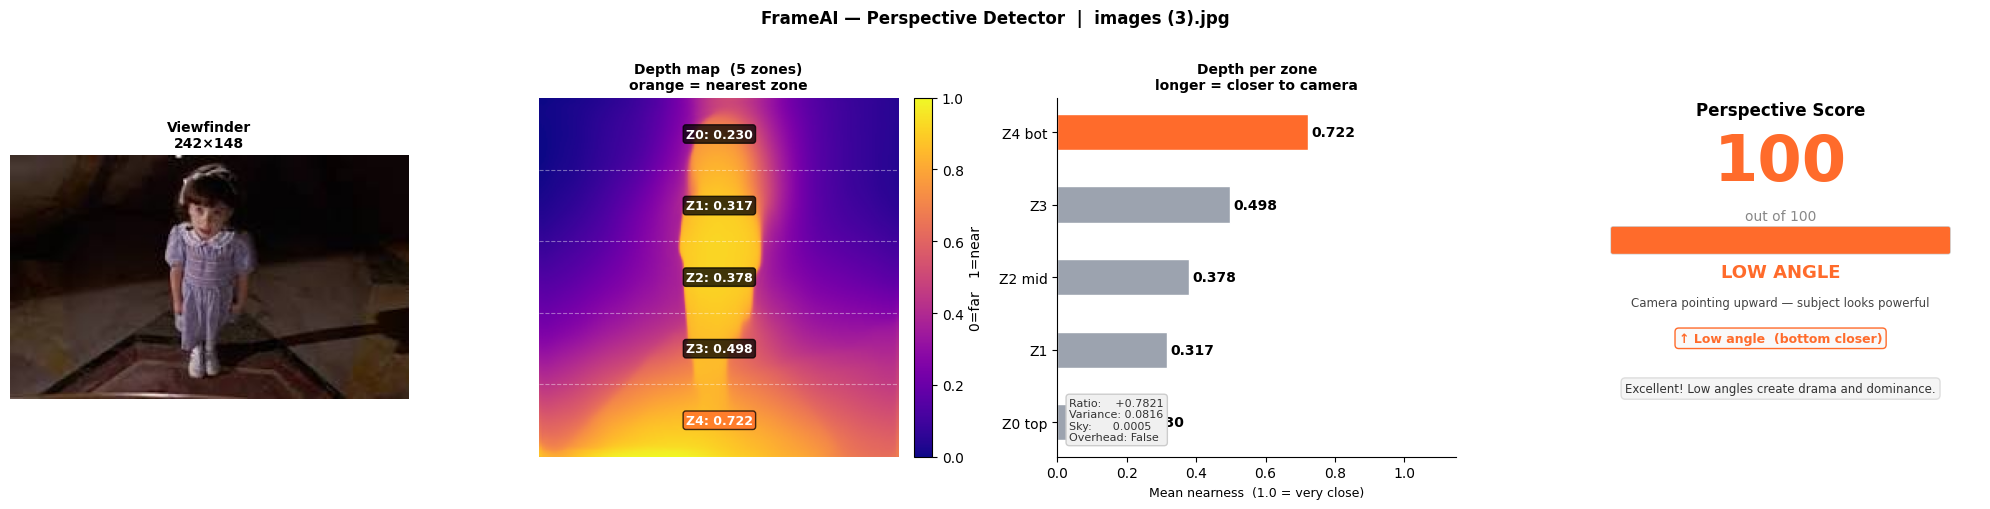

In [25]:
from google.colab import files

print("Upload your photos or screenshots.")
print("Camera app UI (shutter button etc.) will be removed automatically.\n")

uploaded = files.upload()
results  = []

for filename, data in uploaded.items():
    print(f"\n{'='*60}")
    print(f"File: {filename}")
    print('='*60)

    raw = Image.open(io.BytesIO(data)).convert("RGB")
    print(f"Original size: {raw.size[0]}×{raw.size[1]}")

    # Step 1 — Remove camera UI if screenshot
    is_screenshot = ("screenshot" in filename.lower() or
                     "screen" in filename.lower() or
                     raw.size[1] > raw.size[0] * 1.6)   # very tall = phone UI

    if is_screenshot:
        print("  Screenshot detected — removing camera UI...")
        clean = crop_camera_ui(raw)
    else:
        clean = raw
        print("  Regular photo — no crop needed.")

    # Step 2 — Run MiDaS
    depth = run_midas(clean)
    print(f"  Depth map: {depth.shape}  "
          f"range {depth.min():.3f}→{depth.max():.3f}")

    # Step 3 — Analyse angle
    label, score, color, det = analyse_angle(depth, pil_img=clean)
    results.append((filename, raw, clean, depth, label, score, color, det))

    # Step 4 — Print debug info
    print(f"\n  5-zone means (top→bottom): {det['zone_means']}")
    print(f"  Vertical ratio  : {det['vert_ratio']:+.4f}   "
          f"(needs ±0.28 to trigger non-eye-level)")
    print(f"  Depth variance  : {det['variance']:.5f}   "
          f"({'flat' if det['variance']<0.04 else 'varied'})")
    print(f"  Sky ratio       : {det['sky_ratio']:.4f}   "
          f"({'sky present' if det['sky_ratio']>0.05 else 'no sky'})")
    print(f"  Dark top (ceil) : {det['dark_top']}")
    print(f"  Nearest zone    : Z{det['nearest_zone']} "
          f"(0=top … 4=bottom)")
    print(f"  Overhead        : {det['is_overhead']}")
    print(f"\n  RESULT → {label}  |  {score}/100")
    print(f"  TIP    → {det['tip']}")

    # Step 5 — Visualise
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Panel 1 — cleaned viewfinder
    axes[0].imshow(clean)
    axes[0].set_title(f"Viewfinder\n{clean.size[0]}×{clean.size[1]}",
                      fontsize=10, fontweight='bold')
    axes[0].axis('off')

    # Panel 2 — depth map with 5-zone overlays
    im = axes[1].imshow(depth, cmap='plasma', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
                 label='0=far   1=near')
    H_d, W_d = depth.shape
    zs = H_d // 5
    for i in range(1, 5):
        axes[1].axhline(i * zs, color='white', lw=0.8,
                        ls='--', alpha=0.4)
    for i, (zm, zy) in enumerate(zip(det['zone_means'],
                                     [zs*0.5, zs*1.5, zs*2.5,
                                      zs*3.5, zs*4.5])):
        bg_col = '#FF6B2B' if i == det['nearest_zone'] else 'black'
        axes[1].text(W_d // 2, zy, f"Z{i}: {zm:.3f}",
                     ha='center', va='center', fontsize=9,
                     color='white', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.22',
                               facecolor=bg_col, alpha=0.75))
    axes[1].set_title("Depth map  (5 zones)\n"
                      "orange = nearest zone",
                      fontsize=10, fontweight='bold')
    axes[1].axis('off')

    # Panel 3 — horizontal bar chart
    zone_labels = ['Z0 top', 'Z1', 'Z2 mid', 'Z3', 'Z4 bot']
    zone_vals   = det['zone_means']
    bc = ['#FF6B2B' if i == det['nearest_zone'] else '#9CA3AF'
          for i in range(5)]
    bars = axes[2].barh(zone_labels, zone_vals,
                        color=bc, edgecolor='white', height=0.5)
    for bar, val in zip(bars, zone_vals):
        axes[2].text(val + 0.01,
                     bar.get_y() + bar.get_height() / 2,
                     f'{val:.3f}',
                     va='center', fontsize=10, fontweight='bold')
    axes[2].set_xlim(0, 1.15)
    axes[2].set_xlabel("Mean nearness  (1.0 = very close)", fontsize=9)
    axes[2].set_title("Depth per zone\n"
                      "longer = closer to camera",
                      fontsize=10, fontweight='bold')
    axes[2].spines[['top', 'right']].set_visible(False)

    g = det['vert_ratio']
    info = (f"Ratio:    {g:+.4f}\n"
            f"Variance: {det['variance']:.4f}\n"
            f"Sky:      {det['sky_ratio']:.4f}\n"
            f"Overhead: {det['is_overhead']}")
    axes[2].text(0.03, 0.04, info,
                 transform=axes[2].transAxes,
                 fontsize=8, color='#333',
                 verticalalignment='bottom',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#f0f0f0', edgecolor='#ccc'))

    # Panel 4 — result card
    ax = axes[3]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    ax.text(5, 9.5, "Perspective Score",
            ha='center', fontsize=12, fontweight='bold')
    ax.text(5, 7.7, str(score),
            ha='center', fontsize=46, fontweight='bold', color=color)
    ax.text(5, 6.6, "out of 100",
            ha='center', fontsize=10, color='#888')

    bg_bar = mpatches.FancyBboxPatch(
        (0.8, 5.7), 8.4, 0.65,
        boxstyle="round,pad=0.05",
        facecolor='#eeeeee', edgecolor='#cccccc', lw=1)
    fill   = mpatches.FancyBboxPatch(
        (0.8, 5.7), 8.4 * score / 100, 0.65,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor='none')
    ax.add_patch(bg_bar)
    ax.add_patch(fill)

    ax.text(5, 5.0, label,
            ha='center', fontsize=13, fontweight='bold', color=color)
    ax.text(5, 4.2, det['description'],
            ha='center', fontsize=8.5, color='#444',
            multialignment='center')

    arrow = ("↑ Low angle  (bottom closer)"  if g >  0.05 else
             "↓ High angle  (top closer)"    if g < -0.05 else
             "↔ Even depth  →  Eye level")
    ax.text(5, 3.2, arrow,
            ha='center', fontsize=9, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#f9f9f9', edgecolor=color, lw=1))
    ax.text(5, 1.8, det['tip'],
            ha='center', fontsize=8.5, color='#333',
            multialignment='center',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='#f5f5f5', edgecolor='#ddd', lw=1))

    fn_short = filename[:30] + "…" if len(filename) > 30 else filename
    plt.suptitle(f"FrameAI — Perspective Detector  |  {fn_short}",
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# ── Comparison table if multiple photos uploaded ──────────────
if len(results) > 1:
    print("\nCOMPARISON")
    print(f"{'File':<35} {'Angle':<22} {'Score':>6}  {'Ratio':>8}  {'Nearest zone':>14}")
    print("─" * 90)
    for fname, _, _, _, lbl, sc, _, d in results:
        short = (fname[:33] + "…") if len(fname) > 33 else fname
        print(f"{short:<35} {lbl:<22} {sc:>5}/100  "
              f"{d['vert_ratio']:>+8.4f}  "
              f"Z{d['nearest_zone']} "
              f"({'top' if d['nearest_zone']<=1 else 'centre' if d['nearest_zone']==2 else 'bottom'})")

In [26]:
# Run this once model is verified working
from google.colab import drive
import shutil

drive.mount('/content/drive')
dest = '/content/drive/MyDrive/FrameAI_models/midas_small.tflite'
os.makedirs(os.path.dirname(dest), exist_ok=True)
shutil.copy("midas_small.tflite", dest)
print(f"Saved to: {dest}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/FrameAI_models/midas_small.tflite


In [27]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        FrameAI — Complete 6-Rule Composition Analyzer        ║
# ║  Rule of Thirds · Leading Lines · Negative Space · Symmetry  ║
# ║          Framing · Perspective · NIMA Overall Score          ║
# ╚══════════════════════════════════════════════════════════════╝

# ── CELL 1: Install all dependencies ─────────────────────────
!pip install ultralytics tensorflow opencv-python-headless \
             scikit-image Pillow matplotlib numpy -q

print("All packages installed.")

All packages installed.


In [28]:
# ── CELL 2 (FIXED): Download all models — no 403 errors ──────
import os, subprocess

# ── DeepLabV3 ─────────────────────────────────────────────────
# TF Hub blocks urllib directly — use wget with a browser header
# Fallback: pull the file directly from tensorflow/tflite-support GitHub repo

if not os.path.exists("deeplabv3.tflite"):
    print("Downloading DeepLabV3...")

    # Source 1: TF Hub (via wget with browser user-agent)
    r1 = subprocess.run([
        "wget", "-q", "--show-progress",
        "--user-agent",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36",
        "-O", "deeplabv3.tflite",
        "https://storage.googleapis.com/tfhub-lite-models/"
        "tensorflow/lite-model/deeplabv3/1/metadata/2.tflite"
    ], capture_output=True)

    # Check if file is valid (not an HTML error page)
    if (os.path.exists("deeplabv3.tflite") and
            os.path.getsize("deeplabv3.tflite") > 500_000):
        print(f"  Source 1 OK — "
              f"{os.path.getsize('deeplabv3.tflite')//1024} KB")
    else:
        print("  Source 1 failed — trying Source 2 (GitHub tflite-support)...")
        os.remove("deeplabv3.tflite") if os.path.exists("deeplabv3.tflite") else None

        # Source 2: tensorflow/tflite-support GitHub (raw file)
        r2 = subprocess.run([
            "wget", "-q", "--show-progress",
            "-O", "deeplabv3.tflite",
            "https://github.com/tensorflow/tflite-support/raw/master/"
            "tensorflow_lite_support/metadata/python/tests/"
            "testdata/image_segmenter/deeplabv3.tflite"
        ], capture_output=True)

        if (os.path.exists("deeplabv3.tflite") and
                os.path.getsize("deeplabv3.tflite") > 500_000):
            print(f"  Source 2 OK — "
                  f"{os.path.getsize('deeplabv3.tflite')//1024} KB")
        else:
            print("  Source 2 failed — trying Source 3 (git clone)...")
            os.remove("deeplabv3.tflite") if os.path.exists("deeplabv3.tflite") else None

            # Source 3: git clone just the one file using sparse checkout
            subprocess.run([
                "git", "clone", "--filter=blob:none", "--sparse",
                "https://github.com/tensorflow/tflite-support.git",
                "tflite_support_tmp"
            ], capture_output=True)
            subprocess.run([
                "git", "-C", "tflite_support_tmp",
                "sparse-checkout", "set",
                "tensorflow_lite_support/metadata/python/tests/"
                "testdata/image_segmenter/"
            ], capture_output=True)

            src = ("tflite_support_tmp/tensorflow_lite_support/metadata/"
                   "python/tests/testdata/image_segmenter/deeplabv3.tflite")
            if os.path.exists(src):
                import shutil
                shutil.copy(src, "deeplabv3.tflite")
                print(f"  Source 3 OK — "
                      f"{os.path.getsize('deeplabv3.tflite')//1024} KB")
            else:
                print("  All sources failed for DeepLabV3.")
                print("  Manual fix: run this in a new cell:")
                print("  !gdown --id 1GJbL1Uf8R1vlEtJqMEI6KL_fIGv9Dlul "
                      "-O deeplabv3.tflite")
else:
    print(f"  deeplabv3.tflite already exists — "
          f"{os.path.getsize('deeplabv3.tflite')//1024} KB")


# ── MiDaS Small ───────────────────────────────────────────────
if not os.path.exists("midas_small.tflite"):
    print("\nDownloading MiDaS Small v2.1...")

    # Source 1: official GitHub release
    r = subprocess.run([
        "wget", "-q", "--show-progress",
        "-O", "midas_small.tflite",
        "https://github.com/isl-org/MiDaS/releases/"
        "download/v2_1/model_opt.tflite"
    ], capture_output=True)

    if (os.path.exists("midas_small.tflite") and
            os.path.getsize("midas_small.tflite") > 1_000_000):
        mb = os.path.getsize("midas_small.tflite") / 1024 / 1024
        print(f"  MiDaS OK — {mb:.1f} MB")
    else:
        print("  Source 1 failed — trying Source 2...")
        os.remove("midas_small.tflite") if os.path.exists("midas_small.tflite") else None

        # Source 2: older v2 release tag
        subprocess.run([
            "wget", "-q", "--show-progress",
            "-O", "midas_small.tflite",
            "https://github.com/isl-org/MiDaS/releases/"
            "download/v2/model_opt.tflite"
        ], capture_output=True)

        if (os.path.exists("midas_small.tflite") and
                os.path.getsize("midas_small.tflite") > 1_000_000):
            mb = os.path.getsize("midas_small.tflite") / 1024 / 1024
            print(f"  Source 2 OK — {mb:.1f} MB")
        else:
            print("  Both MiDaS sources failed.")
            print("  Manual fix — run this in a new cell:")
            print("  !wget -O midas_small.tflite "
                  "https://github.com/isl-org/MiDaS/releases/"
                  "download/v2_1/model_opt.tflite")
else:
    mb = os.path.getsize("midas_small.tflite") / 1024 / 1024
    print(f"  midas_small.tflite already exists — {mb:.1f} MB")


# ── YOLOv8n (via ultralytics — always works) ──────────────────
print("\nDownloading YOLOv8n...")
from ultralytics import YOLO
YOLO("yolov8n.pt")   # downloads automatically if not present
print(f"  yolov8n.pt OK — "
      f"{os.path.getsize('yolov8n.pt')//1024} KB")


# ── Final check ───────────────────────────────────────────────
print("\n" + "─"*45)
print("MODEL FILES STATUS:")
for fname, min_kb in [
    ("deeplabv3.tflite",   500),
    ("midas_small.tflite", 1000),
    ("yolov8n.pt",         5000),
]:
    if os.path.exists(fname):
        kb = os.path.getsize(fname) // 1024
        ok = "OK" if kb > min_kb else "TOO SMALL — may be corrupt"
        print(f"  {fname:<25} {kb:>6} KB   {ok}")
    else:
        print(f"  {fname:<25}   MISSING")
print("─"*45)
print("\nIf any model shows MISSING or TOO SMALL,")
print("copy the manual fix command above into a new cell and run it.")

  deeplabv3.tflite already exists — 2714 KB
  midas_small.tflite already exists — 63.3 MB

  yolov8n.pt OK — 6396 KB

─────────────────────────────────────────────
MODEL FILES STATUS:
  deeplabv3.tflite            2714 KB   OK
  midas_small.tflite         64783 KB   OK
  yolov8n.pt                  6396 KB   OK
─────────────────────────────────────────────

If any model shows MISSING or TOO SMALL,
copy the manual fix command above into a new cell and run it.


In [30]:
# ── CELL 3: Download and convert NIMA model ───────────────────
import tensorflow as tf
import numpy as np
import warnings, os
warnings.filterwarnings("ignore")

if not os.path.exists("nima_mobilenet.tflite"):
    print("Building NIMA model from idealo weights...")

    from tensorflow.keras.applications import MobileNet
    from tensorflow.keras.layers import Dropout, Dense
    from tensorflow.keras.models import Model

    url = ("https://github.com/idealo/image-quality-assessment"
           "/raw/master/models/MobileNet/"
           "weights_mobilenet_aesthetic_0.07.hdf5")
    urllib.request.urlretrieve(url, "nima_weights.hdf5")

    base = MobileNet(input_shape=(224,224,3), alpha=1,
                     include_top=False, pooling='avg', weights=None)
    x    = Dropout(0.75)(base.output)
    x    = Dense(10, activation='softmax')(x)
    nima = Model(base.input, x)
    nima.load_weights("nima_weights.hdf5")

    converter = tf.lite.TFLiteConverter.from_keras_model(nima)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()

    with open("nima_mobilenet.tflite", "wb") as f:
        f.write(tflite_model)

    mb = os.path.getsize("nima_mobilenet.tflite") / 1024 / 1024
    print(f"  nima_mobilenet.tflite saved — {mb:.1f} MB")
else:
    print("nima_mobilenet.tflite already exists — skipping.")

nima_mobilenet.tflite already exists — skipping.


In [31]:
# ── CELL 4: Load all models into memory ──────────────────────
import tensorflow as tf
import numpy as np
from ultralytics import YOLO
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

print("Loading models...")

# ── YOLOv8n ──────────────────────────────────────────────────
yolo = YOLO("yolov8n.pt")
print("  YOLOv8n         loaded")

# ── DeepLabV3 ────────────────────────────────────────────────
deeplab_interp = tf.lite.Interpreter(model_path="deeplabv3.tflite")
deeplab_interp.allocate_tensors()
dl_inp = deeplab_interp.get_input_details()
dl_out = deeplab_interp.get_output_details()
DL_SIZE = int(dl_inp[0]['shape'][1])   # 257
print(f"  DeepLabV3       loaded  (input {DL_SIZE}×{DL_SIZE})")

# ── MiDaS ────────────────────────────────────────────────────
midas_interp = tf.lite.Interpreter(model_path="midas_small.tflite")
midas_interp.allocate_tensors()
md_inp = midas_interp.get_input_details()
md_out = midas_interp.get_output_details()
MD_H   = int(md_inp[0]['shape'][1])    # 256
MD_W   = int(md_inp[0]['shape'][2])    # 256
print(f"  MiDaS Small     loaded  (input {MD_W}×{MD_H})")

# ── NIMA ─────────────────────────────────────────────────────
nima_interp = tf.lite.Interpreter(model_path="nima_mobilenet.tflite")
nima_interp.allocate_tensors()
nm_inp = nima_interp.get_input_details()
nm_out = nima_interp.get_output_details()
print("  NIMA MobileNet  loaded")

print("\nAll models loaded and ready.")

Loading models...
  YOLOv8n         loaded
  DeepLabV3       loaded  (input 257×257)
  MiDaS Small     loaded  (input 256×256)
  NIMA MobileNet  loaded

All models loaded and ready.


In [32]:
# ── CELL 5: All analysis functions ───────────────────────────
import cv2
from skimage.metrics import structural_similarity as ssim

# ─────────────────────────────────────────────────────────────
# UTIL — crop camera screenshot UI
# ─────────────────────────────────────────────────────────────
def crop_ui(pil_img):
    W, H  = pil_img.size
    arr   = np.array(pil_img.convert("RGB"), dtype=np.float32)
    gray  = np.mean(arr, axis=2)

    win    = 15
    edges  = np.array([np.mean(np.abs(gray[y] - gray[y-1]))
                       for y in range(H)])
    sm_e   = np.convolve(edges, np.ones(win)/win, mode='same')
    et     = np.percentile(sm_e[H//4:3*H//4], 30)

    top, bot = 0, H
    for y in range(H//3):
        if sm_e[y] > et: top = y; break
    for y in range(H-1, H*2//3, -1):
        if sm_e[y] > et: bot = y; break

    top_f = int(H * 0.175)
    bot_f = int(H * 0.660)
    top   = int(np.median([top, top_f, top_f]))
    bot   = int(np.median([bot, bot_f, bot_f]))
    top   = max(int(H*0.10), min(top, int(H*0.25)))
    bot   = max(int(H*0.58), min(bot, int(H*0.75)))
    if bot - top < H * 0.35:
        top, bot = int(H*0.175), int(H*0.660)
    return pil_img.crop((0, top, W, bot))


# ─────────────────────────────────────────────────────────────
# RULE 1 — Rule of Thirds  (YOLOv8n)
# ─────────────────────────────────────────────────────────────
def rule_of_thirds(pil_img):
    """
    Detects subject with YOLOv8n.
    Checks if subject centre is within 12% of a third intersection.
    Returns score 0-100 and best tip.
    """
    results = yolo(pil_img, verbose=False)
    W, H    = pil_img.size

    # Third intersection points (as fractions)
    intersections = [(1/3, 1/3), (2/3, 1/3),
                     (1/3, 2/3), (2/3, 2/3)]

    best_score = 0
    best_tip   = "No subject detected — point at a clear subject."
    best_box   = None

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cx = ((x1 + x2) / 2) / W   # normalise to 0-1
            cy = ((y1 + y2) / 2) / H

            # Distance to nearest intersection
            min_dist = min(
                ((cx - ix)**2 + (cy - iy)**2)**0.5
                for ix, iy in intersections
            )
            # Score: 100 if perfectly on intersection, 0 if far
            s = max(0, int((1 - min_dist / 0.50) * 100))

            if s > best_score:
                best_score = s
                best_box   = (x1, y1, x2, y2, cx, cy)

                # Which intersection is nearest?
                nearest = min(intersections,
                              key=lambda p: (cx-p[0])**2 + (cy-p[1])**2)
                h_dir = "left"  if cx > nearest[0] + 0.05 else \
                        "right" if cx < nearest[0] - 0.05 else ""
                v_dir = "down"  if cy > nearest[1] + 0.05 else \
                        "up"    if cy < nearest[1] - 0.05 else ""
                direction = " and ".join(filter(None, [h_dir, v_dir]))

                if s >= 80:
                    best_tip = "Subject is at a strong third intersection. "
                elif direction:
                    best_tip = f"Move subject {direction} to hit a third intersection."
                else:
                    best_tip = "Adjust framing slightly for Rule of Thirds."

    return best_score, best_tip, best_box


# ─────────────────────────────────────────────────────────────
# RULE 2 — Leading Lines  (OpenCV Hough)
# ─────────────────────────────────────────────────────────────
def leading_lines(pil_img):
    """
    Uses Canny edge detection + Hough Line Transform.
    Checks if strong lines point toward the centre of the frame.
    Returns score 0-100 and detected line segments.
    """
    img_cv  = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    gray_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    H, W    = gray_cv.shape

    # Canny edge detection
    blurred = cv2.GaussianBlur(gray_cv, (5, 5), 0)
    edges   = cv2.Canny(blurred, 50, 150)

    # Probabilistic Hough Line Transform
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=int(min(W, H) * 0.20),
        maxLineGap=int(min(W, H) * 0.05)
    )

    if lines is None:
        return 0, "No leading lines detected. Look for roads, paths, or railings.", []

    cx, cy    = W / 2, H / 2
    converging = 0
    total      = len(lines)
    good_lines = []

    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = ((x2-x1)**2 + (y2-y1)**2) ** 0.5

        # Midpoint of this line
        mx, my = (x1+x2)/2, (y1+y2)/2

        # Direction vector of the line
        dx, dy = x2-x1, y2-y1
        norm   = (dx**2+dy**2)**0.5 + 1e-6

        # Vector from midpoint to frame centre
        tcx, tcy = cx-mx, cy-my
        t_norm   = (tcx**2+tcy**2)**0.5 + 1e-6

        # Dot product — positive = line points toward centre
        dot = (dx*tcx + dy*tcy) / (norm * t_norm)

        if abs(dot) > 0.55:    # roughly aligned toward centre
            converging += 1
            good_lines.append((x1, y1, x2, y2))

    if total == 0:
        return 0, "No lines found.", []

    ratio = converging / total
    score = int(min(ratio / 0.4, 1.0) * 100)

    if score >= 75:
        tip = f"{converging} strong leading lines guide the eye inward. Excellent!"
    elif score >= 40:
        tip = f"{converging} partial leading lines. Try including a road or path."
    else:
        tip = "Lines don't guide toward subject. Find a path, fence, or corridor."

    return score, tip, good_lines


# ─────────────────────────────────────────────────────────────
# RULE 3 — Negative Space  (YOLOv8n bbox area ratio)
# ─────────────────────────────────────────────────────────────
def negative_space(pil_img):
    """
    Subject area ÷ frame area.
    If subject takes < 35% of frame → good negative space.
    Returns score 0-100.
    """
    results  = yolo(pil_img, verbose=False)
    W, H     = pil_img.size
    frame_area = W * H

    largest_area = 0
    best_box     = None

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            area = (x2 - x1) * (y2 - y1)
            if area > largest_area:
                largest_area = area
                best_box     = (x1, y1, x2, y2)

    if largest_area == 0:
        return 50, "No subject detected. Score is neutral.", None

    ratio = largest_area / frame_area   # 0.0 to 1.0

    # Ideal: subject fills 15-35% of frame
    # Too small (<10%): subject lost in space
    # Too large (>60%): no breathing room
    if 0.10 <= ratio <= 0.35:
        score = int(90 + (0.225 - abs(ratio - 0.225)) / 0.225 * 10)
        tip   = f"Subject fills {ratio*100:.0f}% of frame — ideal negative space."
    elif ratio < 0.10:
        score = int(ratio / 0.10 * 60)
        tip   = f"Subject too small ({ratio*100:.0f}%). Move closer."
    elif ratio <= 0.55:
        score = int((1 - (ratio - 0.35) / 0.20) * 70)
        tip   = f"Subject fills {ratio*100:.0f}% — slightly cramped. Step back a little."
    else:
        score = int(max(0, (1 - (ratio - 0.55) / 0.45) * 40))
        tip   = f"Subject fills {ratio*100:.0f}% — very tight. Step back for breathing room."

    score = max(0, min(100, score))
    return score, tip, best_box


# ─────────────────────────────────────────────────────────────
# RULE 4 — Symmetry  (OpenCV SSIM)
# ─────────────────────────────────────────────────────────────
def symmetry(pil_img):
    """
    Flips image left-right and top-bottom.
    Compares with SSIM — high similarity = strong symmetry.
    Returns score 0-100.
    """
    img_gray = np.array(pil_img.convert("L").resize((256, 256)))

    # Left-right symmetry
    flipped_lr = np.fliplr(img_gray)
    score_lr   = ssim(img_gray, flipped_lr, data_range=255)

    # Top-bottom symmetry
    flipped_tb = np.flipud(img_gray)
    score_tb   = ssim(img_gray, flipped_tb, data_range=255)

    # Use the stronger of the two
    best_ssim = max(score_lr, score_tb)
    direction = "left-right" if score_lr >= score_tb else "top-bottom"

    # SSIM range: ~0.3 (random) to 1.0 (identical)
    # Map 0.3-0.95 to 0-100
    score = int(max(0, (best_ssim - 0.30) / 0.65) * 100)
    score = max(0, min(100, score))

    if score >= 75:
        tip = f"Strong {direction} symmetry detected — very balanced composition."
    elif score >= 45:
        tip = f"Partial {direction} symmetry. Centre your subject for stronger balance."
    else:
        tip = "No strong symmetry. For symmetry: centre subject, use reflections."

    return score, tip, score_lr, score_tb


# ─────────────────────────────────────────────────────────────
# RULE 5 — Framing  (DeepLabV3)
# ─────────────────────────────────────────────────────────────
DEEPLAB_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle',
    'bus','car','cat','chair','cow','dining table','dog','horse',
    'motorbike','person','potted plant','sheep','sofa','train','tv'
]

def framing(pil_img):
    """
    Runs DeepLabV3 semantic segmentation.
    If subject (centre pixel class) is surrounded by
    different-class pixels on 3+ sides → framing detected.
    Returns score 0-100.
    """
    img_r  = pil_img.resize((DL_SIZE, DL_SIZE))
    arr    = (np.array(img_r.convert("RGB"),
              dtype=np.float32) / 255.0)
    batch  = np.expand_dims(arr, axis=0)

    deeplab_interp.set_tensor(dl_inp[0]['index'], batch)
    deeplab_interp.invoke()
    raw = deeplab_interp.get_tensor(dl_out[0]['index'])

    if len(raw.shape) == 4:
        seg = np.argmax(raw[0], axis=-1)
    else:
        seg = raw[0].astype(np.int32)

    H, W  = seg.shape
    STRIP = int(H * 0.18)
    cx1, cx2 = int(W * 0.28), int(W * 0.72)
    cy1, cy2 = int(H * 0.22), int(H * 0.78)

    centre = seg[cy1:cy2, cx1:cx2].flatten()
    counts = np.bincount(centre, minlength=21)
    if counts[1:].sum() > 0:
        counts[0] = 0   # prefer real object over background
    subj_cls  = int(np.argmax(counts))
    subj_name = (DEEPLAB_CLASSES[subj_cls]
                 if subj_cls < len(DEEPLAB_CLASSES)
                 else f"class_{subj_cls}")

    strips = {
        "TOP"   : seg[0:STRIP,    cx1:cx2],
        "BOTTOM": seg[H-STRIP:H,  cx1:cx2],
        "LEFT"  : seg[cy1:cy2,    0:STRIP],
        "RIGHT" : seg[cy1:cy2,    W-STRIP:W],
    }

    framing_sides = []
    for side, region in strips.items():
        if region.size == 0:
            continue
        dom = int(np.bincount(region.flatten(), minlength=21).argmax())
        if dom != subj_cls:
            framing_sides.append(side)

    n     = len(framing_sides)
    score = {0:0, 1:25, 2:55, 3:80, 4:98}[n]

    if n >= 3:
        tip = f"Subject framed on {n} sides ({', '.join(framing_sides)}). Excellent!"
    elif n == 2:
        miss = [s for s in ["TOP","BOTTOM","LEFT","RIGHT"]
                if s not in framing_sides]
        tip = f"Partial framing. Add an element on the {miss[0]} side."
    elif n == 1:
        tip = "Weak framing. Try shooting through a doorway or between trees."
    else:
        tip = "No framing. Look for windows, arches, or branches to frame subject."

    return score, tip, subj_name, framing_sides, seg


# ─────────────────────────────────────────────────────────────
# RULE 6 — Perspective / Angle  (MiDaS)
# ─────────────────────────────────────────────────────────────
def perspective(pil_img):
    """
    Runs MiDaS depth estimation.
    Analyses vertical depth gradient to classify camera angle.
    Returns score 0-100 and angle label.
    """
    img_r  = pil_img.convert("RGB").resize((MD_W, MD_H))
    arr    = ((np.array(img_r, dtype=np.float32) / 127.5) - 1.0)
    batch  = np.expand_dims(arr, axis=0)

    midas_interp.set_tensor(md_inp[0]['index'], batch)
    midas_interp.invoke()
    raw = midas_interp.get_tensor(md_out[0]['index']).squeeze()

    lo, hi = raw.min(), raw.max()
    depth  = (raw - lo) / (hi - lo) if hi - lo > 1e-6 else raw

    H, W  = depth.shape
    zs    = H // 5
    zones = [float(np.mean(depth[i*zs:(i+1)*zs, :]))
             for i in range(5)]

    top_m = float(np.mean(zones[0:2]))
    bot_m = float(np.mean(zones[3:5]))
    ovr   = float(np.mean(depth))
    var   = float(np.var(depth))
    vdiff = bot_m - top_m
    vratio = vdiff / ovr if ovr > 1e-6 else 0.0
    nz    = int(np.argmax(zones))

    # Cross-validate with pixel info
    rgb       = np.array(pil_img.convert("RGB").resize((W, H)),
                         dtype=np.float32) / 255.0
    tr        = rgb[:H//3, :, :]
    sky_mask  = ((tr[:,:,2] > tr[:,:,0]+0.05) &
                 (tr[:,:,2] > tr[:,:,1]) &
                 (tr[:,:,2] > 0.35))
    sky_r     = float(np.mean(sky_mask))
    gray_px   = np.mean(rgb, axis=2)
    top_br    = float(np.mean(gray_px[:H//4, :]))
    bot_br    = float(np.mean(gray_px[3*H//4:, :]))
    dark_top  = top_br < 0.18 and bot_br > top_br + 0.12
    overhead  = (sky_r < 0.05 and var < 0.04 and abs(vdiff) < 0.25)
    if sky_r < 0.05 and var < 0.025:
        overhead = True

    STRONG, MOD, MIND = 0.28, 0.12, 0.07

    if overhead:
        label, score, tip = ("HIGH ANGLE", 75,
            "Overhead shot. Try an angle for more depth.")
    elif vratio > STRONG and vdiff > MIND and (sky_r>0.04 or dark_top or nz>=3):
        label = "LOW ANGLE"
        score = int(min(vratio/0.55,1.0)*100)
        tip   = "Excellent low angle — creates drama and dominance."
    elif vratio > MOD and vdiff > MIND*0.6 and (sky_r>0.02 or dark_top or nz>=3):
        label = "SLIGHT LOW ANGLE"
        score = int(min(vratio/0.55,1.0)*100)
        tip   = "Slight low angle. Try going lower for more drama."
    elif vratio < -STRONG and abs(vdiff) > MIND:
        label = "HIGH ANGLE"
        score = int(min(abs(vratio)/0.55,1.0)*100)
        tip   = "High angle — good for overview shots."
    elif vratio < -MOD and abs(vdiff) > MIND*0.6:
        label = "SLIGHT HIGH ANGLE"
        score = int(min(abs(vratio)/0.55,1.0)*100)
        tip   = "Slight high angle. Try going higher for more impact."
    else:
        label = "EYE LEVEL"
        score = int(min(var/0.04,1.0)*45)
        tip   = "Eye level — try crouching or raising camera."

    return max(0,min(100,score)), tip, label, depth, zones


# ─────────────────────────────────────────────────────────────
# NIMA — Overall aesthetic score
# ─────────────────────────────────────────────────────────────
def nima_score(pil_img):
    """
    Runs NIMA MobileNet on a 224×224 image.
    Returns mean aesthetic score 0-100.
    """
    img_r = pil_img.convert("RGB").resize((224, 224))
    arr   = np.array(img_r, dtype=np.float32) / 255.0
    batch = np.expand_dims(arr, axis=0)

    nima_interp.set_tensor(nm_inp[0]['index'], batch)
    nima_interp.invoke()
    dist  = nima_interp.get_tensor(nm_out[0]['index'])[0]

    mean  = float(np.sum(dist * np.arange(1, 11))) / 10 * 100
    mean  = max(0, min(100, mean))

    if mean >= 65:
        tip = "Strong overall aesthetic quality."
    elif mean >= 45:
        tip = "Average quality. Improve composition for better results."
    else:
        tip = "Low aesthetic score. Focus on lighting and subject placement."

    return round(mean, 1), tip


# ─────────────────────────────────────────────────────────────
# MASTER — Run all 6 rules + NIMA on one image
# ─────────────────────────────────────────────────────────────
def analyse_photo(pil_img, label="Photo"):
    """Runs all 6 composition rules and NIMA on one image."""

    print(f"\n  Analysing '{label}' ({pil_img.size[0]}×{pil_img.size[1]})...")

    r1_score, r1_tip, r1_box         = rule_of_thirds(pil_img)
    r2_score, r2_tip, r2_lines       = leading_lines(pil_img)
    r3_score, r3_tip, r3_box         = negative_space(pil_img)
    r4_score, r4_tip, r4_lr, r4_tb   = symmetry(pil_img)
    r5_score, r5_tip, r5_subj, r5_sides, r5_seg = framing(pil_img)
    r6_score, r6_tip, r6_angle, r6_depth, r6_zones = perspective(pil_img)
    n_score,  n_tip                  = nima_score(pil_img)

    overall = int(np.mean([r1_score, r2_score, r3_score,
                            r4_score, r5_score, r6_score]))

    return {
        "label"    : label,
        "image"    : pil_img,
        "overall"  : overall,
        "nima"     : n_score,
        "rules"    : {
            "Rule of Thirds" : (r1_score, r1_tip, r1_box),
            "Leading Lines"  : (r2_score, r2_tip, r2_lines),
            "Negative Space" : (r3_score, r3_tip, r3_box),
            "Symmetry"       : (r4_score, r4_tip, r4_lr),
            "Framing"        : (r5_score, r5_tip, r5_subj),
            "Perspective"    : (r6_score, r6_tip, r6_angle),
        },
        "extra" : {
            "depth_map" : r6_depth,
            "seg_map"   : r5_seg,
            "ll_lines"  : r2_lines,
            "yolo_box"  : r1_box,
        }
    }

print("All 6 analysis functions + NIMA loaded and ready.")

All 6 analysis functions + NIMA loaded and ready.


In [ ]:
#From this point onward,the model will be tested.(Most important section)




In [44]:
# ── CELL 6: Upload photos and run full analysis ───────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import io
from google.colab import files

print("Upload your photos.")
print("For best results: upload PAIRS — original first, then edited version.")
print("Example: flat_photo.jpg  then  low_angle_edit.jpg\n")

uploaded = files.upload()

photos  = []
results = []

for filename, data in uploaded.items():
    print(f"\nLoading: {filename}")

    raw = Image.open(io.BytesIO(data)).convert("RGB")

    # Auto-detect screenshot and crop UI
    is_ss = ("screenshot" in filename.lower() or
             "screen"     in filename.lower() or
             raw.size[1]  > raw.size[0] * 1.55)
    if is_ss:
        print("  Screenshot detected — cropping camera UI...")
        img = crop_ui(raw)
    else:
        img = raw

    # Use filename (without extension) as label
    lbl = os.path.splitext(filename)[0][:30]
    photos.append((lbl, img))

print(f"\n{len(photos)} photo(s) loaded.")
print("Running analysis — this may take 30-60 seconds per photo...\n")

for lbl, img in photos:
    print(f"{'─'*55}")
    res = analyse_photo(img, label=lbl)
    results.append(res)
    print(f"  Done  →  overall={res['overall']}/100  "
          f"NIMA={res['nima']}/100")

Upload your photos.
For best results: upload PAIRS — original first, then edited version.
Example: flat_photo.jpg  then  low_angle_edit.jpg



Saving Screenshot_2026-03-18-10-31-1_com.android.camera.jpg to Screenshot_2026-03-18-10-31-1_com.android.camera.jpg
Saving Screenshot_2026-03-18-10-31-2_com.android.camera.jpg to Screenshot_2026-03-18-10-31-2_com.android.camera.jpg

Loading: Screenshot_2026-03-18-10-31-1_com.android.camera.jpg
  Screenshot detected — cropping camera UI...

Loading: Screenshot_2026-03-18-10-31-2_com.android.camera.jpg
  Screenshot detected — cropping camera UI...

2 photo(s) loaded.
Running analysis — this may take 30-60 seconds per photo...

───────────────────────────────────────────────────────

  Analysing 'Screenshot_2026-03-18-10-31-1_' (1220×1315)...
  Done  →  overall=31/100  NIMA=34.7/100
───────────────────────────────────────────────────────

  Analysing 'Screenshot_2026-03-18-10-31-2_' (1220×1315)...
  Done  →  overall=68/100  NIMA=38.8/100


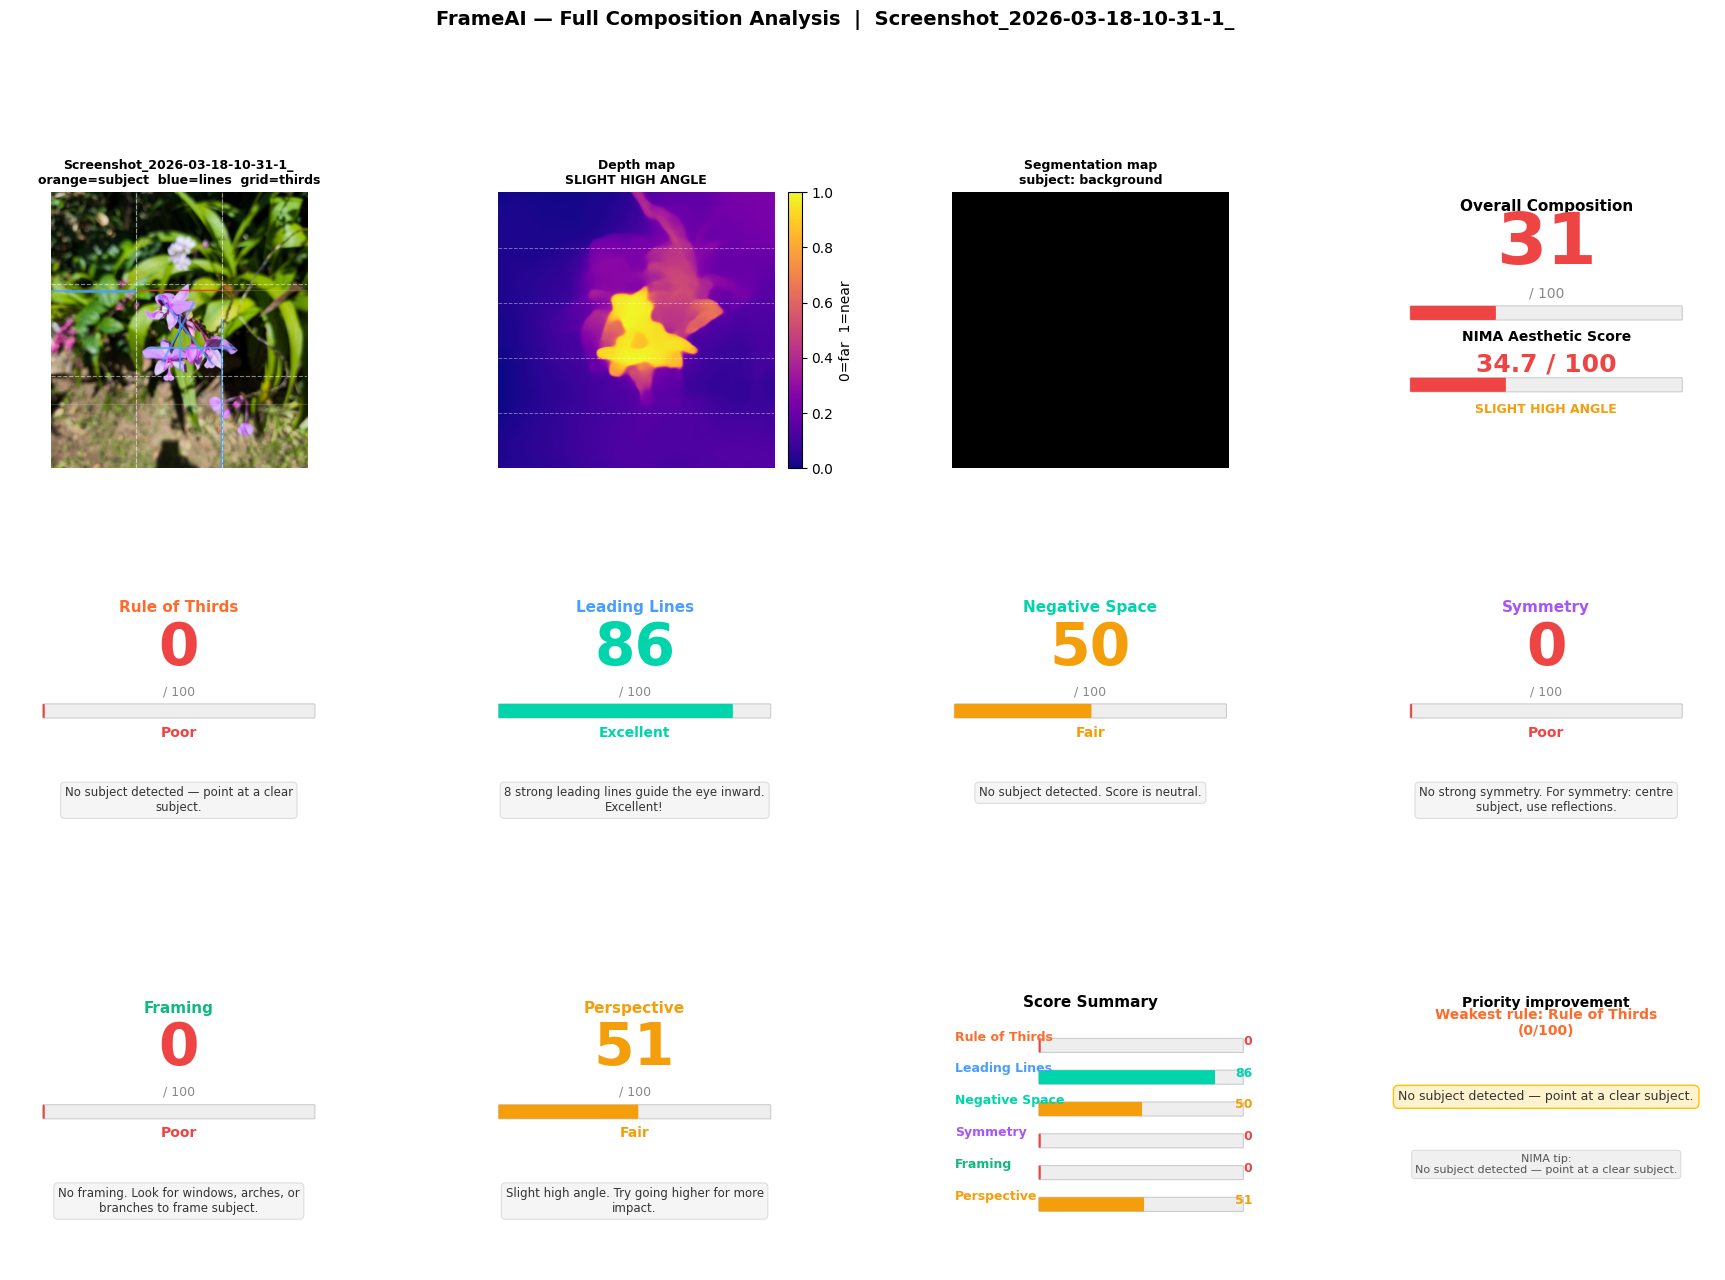


Screenshot_2026-03-18-10-31-1_  — analysis complete


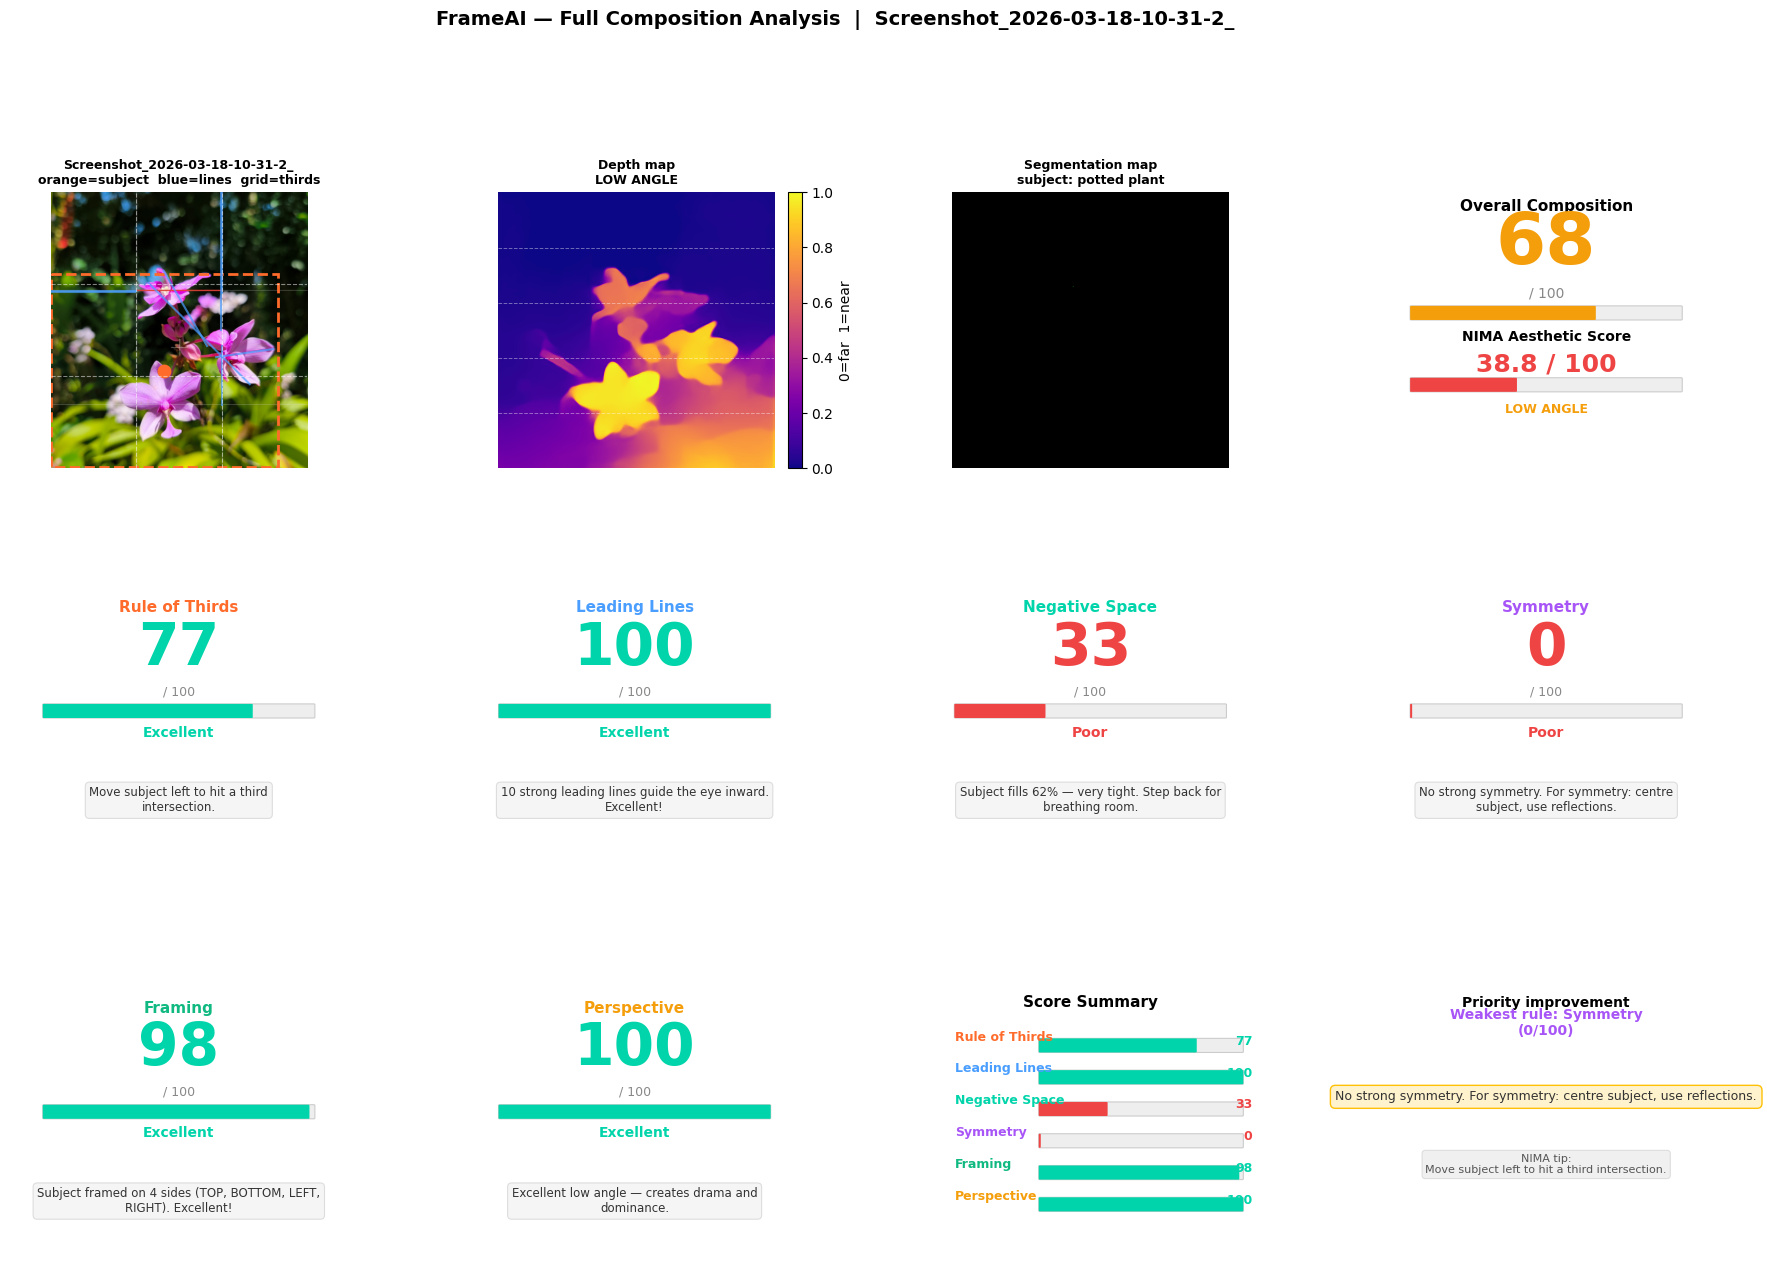


Screenshot_2026-03-18-10-31-2_  — analysis complete


In [45]:
# ── CELL 7: Full visualisation ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# Colour palette
RULE_COLORS = {
    "Rule of Thirds" : "#FF6B2B",
    "Leading Lines"  : "#4A9EFF",
    "Negative Space" : "#00D4AA",
    "Symmetry"       : "#A855F7",
    "Framing"        : "#10B981",
    "Perspective"    : "#F59E0B",
}

def score_color(s):
    if s >= 70: return "#00D4AA"
    if s >= 45: return "#F59E0B"
    return "#EF4444"

def draw_score_bar(ax, y, score, color, width=8.0, x=1.0):
    bg   = mpatches.FancyBboxPatch(
        (x, y), width, 0.45,
        boxstyle="round,pad=0.03",
        facecolor='#eeeeee', edgecolor='#cccccc', lw=0.8)
    fill = mpatches.FancyBboxPatch(
        (x, y), width * score/100, 0.45,
        boxstyle="round,pad=0.03",
        facecolor=color, edgecolor='none')
    ax.add_patch(bg)
    ax.add_patch(fill)

for res in results:
    img    = res['image']
    rules  = res['rules']
    extra  = res['extra']
    W, H   = img.size

    fig = plt.figure(figsize=(22, 14))
    gs  = gridspec.GridSpec(3, 4, figure=fig,
                            hspace=0.45, wspace=0.35)

    # ── Row 0: Photo + YOLO overlay, Depth map, Seg map, Overall ──
    ax_photo = fig.add_subplot(gs[0, 0])
    ax_depth = fig.add_subplot(gs[0, 1])
    ax_seg   = fig.add_subplot(gs[0, 2])
    ax_over  = fig.add_subplot(gs[0, 3])

    # Photo with overlays
    ax_photo.imshow(img)
    # YOLOv8 box (Rule of Thirds + Negative Space)
    if extra['yolo_box']:
        x1, y1, x2, y2, cx, cy = extra['yolo_box']
        rect = mpatches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            lw=2, edgecolor='#FF6B2B',
            facecolor='none', linestyle='--')
        ax_photo.add_patch(rect)
        ax_photo.plot(cx*W, cy*H, 'o',
                      color='#FF6B2B', ms=8, mew=2)
    # Leading lines overlay
    for x1l, y1l, x2l, y2l in extra['ll_lines'][:8]:
        ax_photo.plot([x1l, x2l], [y1l, y2l],
                      color='#4A9EFF', lw=1.5, alpha=0.7)
    # Rule-of-thirds grid
    for f in [1/3, 2/3]:
        ax_photo.axvline(W*f, color='white', lw=0.8,
                         ls='--', alpha=0.5)
        ax_photo.axhline(H*f, color='white', lw=0.8,
                         ls='--', alpha=0.5)
    ax_photo.set_title(
        f"{res['label']}\norange=subject  blue=lines  grid=thirds",
        fontsize=9, fontweight='bold')
    ax_photo.axis('off')

    # Depth map
    depth = extra['depth_map']
    im_d  = ax_depth.imshow(depth, cmap='plasma', vmin=0, vmax=1)
    plt.colorbar(im_d, ax=ax_depth, fraction=0.046, pad=0.04,
                 label='0=far  1=near')
    Hd, Wd = depth.shape
    zs_d   = Hd // 5
    for i in range(1, 5):
        ax_depth.axhline(i*zs_d, color='white',
                         lw=0.7, ls='--', alpha=0.4)
    ax_depth.set_title(
        f"Depth map\n{rules['Perspective'][2]}",
        fontsize=9, fontweight='bold')
    ax_depth.axis('off')

    # Segmentation map
    SEG_COLORS = np.array([
        [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
        [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
        [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
        [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],
        [0,64,128]], dtype=np.uint8)
    seg     = extra['seg_map']
    seg_col = SEG_COLORS[seg % 21]
    ax_seg.imshow(seg_col)
    ax_seg.set_title(
        f"Segmentation map\nsubject: {rules['Framing'][2]}",
        fontsize=9, fontweight='bold')
    ax_seg.axis('off')

    # Overall score card
    ax_over.set_xlim(0,10); ax_over.set_ylim(0,10); ax_over.axis('off')
    oc = score_color(res['overall'])
    nc = score_color(res['nima'])
    ax_over.text(5, 9.3, "Overall Composition",
                 ha='center', fontsize=11, fontweight='bold')
    ax_over.text(5, 7.4, str(res['overall']),
                 ha='center', fontsize=52,
                 fontweight='bold', color=oc)
    ax_over.text(5, 6.2, "/ 100", ha='center',
                 fontsize=10, color='#888')
    draw_score_bar(ax_over, 5.4, res['overall'], oc)
    ax_over.text(5, 4.6, "NIMA Aesthetic Score",
                 ha='center', fontsize=10, fontweight='bold')
    ax_over.text(5, 3.5, f"{res['nima']} / 100",
                 ha='center', fontsize=18,
                 fontweight='bold', color=nc)
    draw_score_bar(ax_over, 2.8, res['nima'], nc)
    ax_over.text(5, 2.0, rules['Perspective'][2],
                 ha='center', fontsize=9,
                 color=RULE_COLORS['Perspective'],
                 fontweight='bold')

    # ── Rows 1-2: One panel per rule ──────────────────────────
    rule_axes = [
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[1, 3]),
        fig.add_subplot(gs[2, 0]),
        fig.add_subplot(gs[2, 1]),
    ]

    rule_items = list(rules.items())
    for ax, (rname, (rscore, rtip, *_)) in zip(rule_axes, rule_items):
        rc = RULE_COLORS.get(rname, '#888')
        sc = score_color(rscore)

        ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
        # Rule name
        ax.text(5, 9.3, rname,
                ha='center', fontsize=11, fontweight='bold', color=rc)
        # Score number
        ax.text(5, 7.4, str(rscore),
                ha='center', fontsize=42, fontweight='bold', color=sc)
        ax.text(5, 6.3, "/ 100",
                ha='center', fontsize=9, color='#888')
        # Score bar
        draw_score_bar(ax, 5.5, rscore, sc)
        # Rating label
        rating = ("Excellent" if rscore >= 75 else
                  "Good"      if rscore >= 55 else
                  "Fair"      if rscore >= 35 else
                  "Poor")
        ax.text(5, 4.8, rating,
                ha='center', fontsize=10,
                fontweight='bold', color=sc)
        # Tip
        # Wrap tip to max 45 chars per line
        words = rtip.split()
        lines_tip, cur = [], ""
        for w in words:
            if len(cur)+len(w)+1 <= 45:
                cur += (" " if cur else "") + w
            else:
                lines_tip.append(cur); cur = w
        if cur: lines_tip.append(cur)
        tip_txt = "\n".join(lines_tip[:3])
        ax.text(5, 3.0, tip_txt,
                ha='center', fontsize=8.5, color='#333',
                multialignment='center', va='top',
                bbox=dict(boxstyle='round,pad=0.35',
                          facecolor='#f5f5f5',
                          edgecolor='#ddd', lw=0.8))

    # Unused panel (2,2) and (2,3) — summary text
    ax_sum = fig.add_subplot(gs[2, 2])
    ax_sum.set_xlim(0,10); ax_sum.set_ylim(0,10); ax_sum.axis('off')
    ax_sum.text(5, 9.5, "Score Summary",
                ha='center', fontsize=11, fontweight='bold')
    for i, (rn, (rs, rt, *_)) in enumerate(rule_items):
        sc = score_color(rs)
        y  = 8.3 - i * 1.15
        ax_sum.text(1.0, y, rn,
                    fontsize=9, color=RULE_COLORS.get(rn,'#888'),
                    fontweight='bold')
        draw_score_bar(ax_sum, y-0.4, rs,
                       sc, width=6.0, x=3.5)
        ax_sum.text(9.8, y-0.15, str(rs),
                    fontsize=9, fontweight='bold',
                    color=sc, ha='right')

    # Weakest rule
    weakest = min(rule_items, key=lambda x: x[1][0])
    ax_tips = fig.add_subplot(gs[2, 3])
    ax_tips.set_xlim(0,10); ax_tips.set_ylim(0,10); ax_tips.axis('off')
    ax_tips.text(5, 9.5, "Priority improvement",
                 ha='center', fontsize=10, fontweight='bold')
    ax_tips.text(5, 8.5,
                 f"Weakest rule: {weakest[0]}\n({weakest[1][0]}/100)",
                 ha='center', fontsize=10,
                 color=RULE_COLORS.get(weakest[0],'#888'),
                 fontweight='bold', multialignment='center')
    ax_tips.text(5, 6.5, weakest[1][1],
                 ha='center', fontsize=9, color='#333',
                 multialignment='center', va='top',
                 bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='#fff3cd',
                           edgecolor='#ffc107', lw=1))
    ax_tips.text(5, 3.5, f"NIMA tip:\n{rules['Rule of Thirds'][1]}",
                 ha='center', fontsize=8, color='#555',
                 multialignment='center',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#f0f0f0',
                           edgecolor='#ddd', lw=0.8))

    plt.suptitle(
        f"FrameAI — Full Composition Analysis  |  {res['label']}",
        fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"\n{res['label']}  — analysis complete")

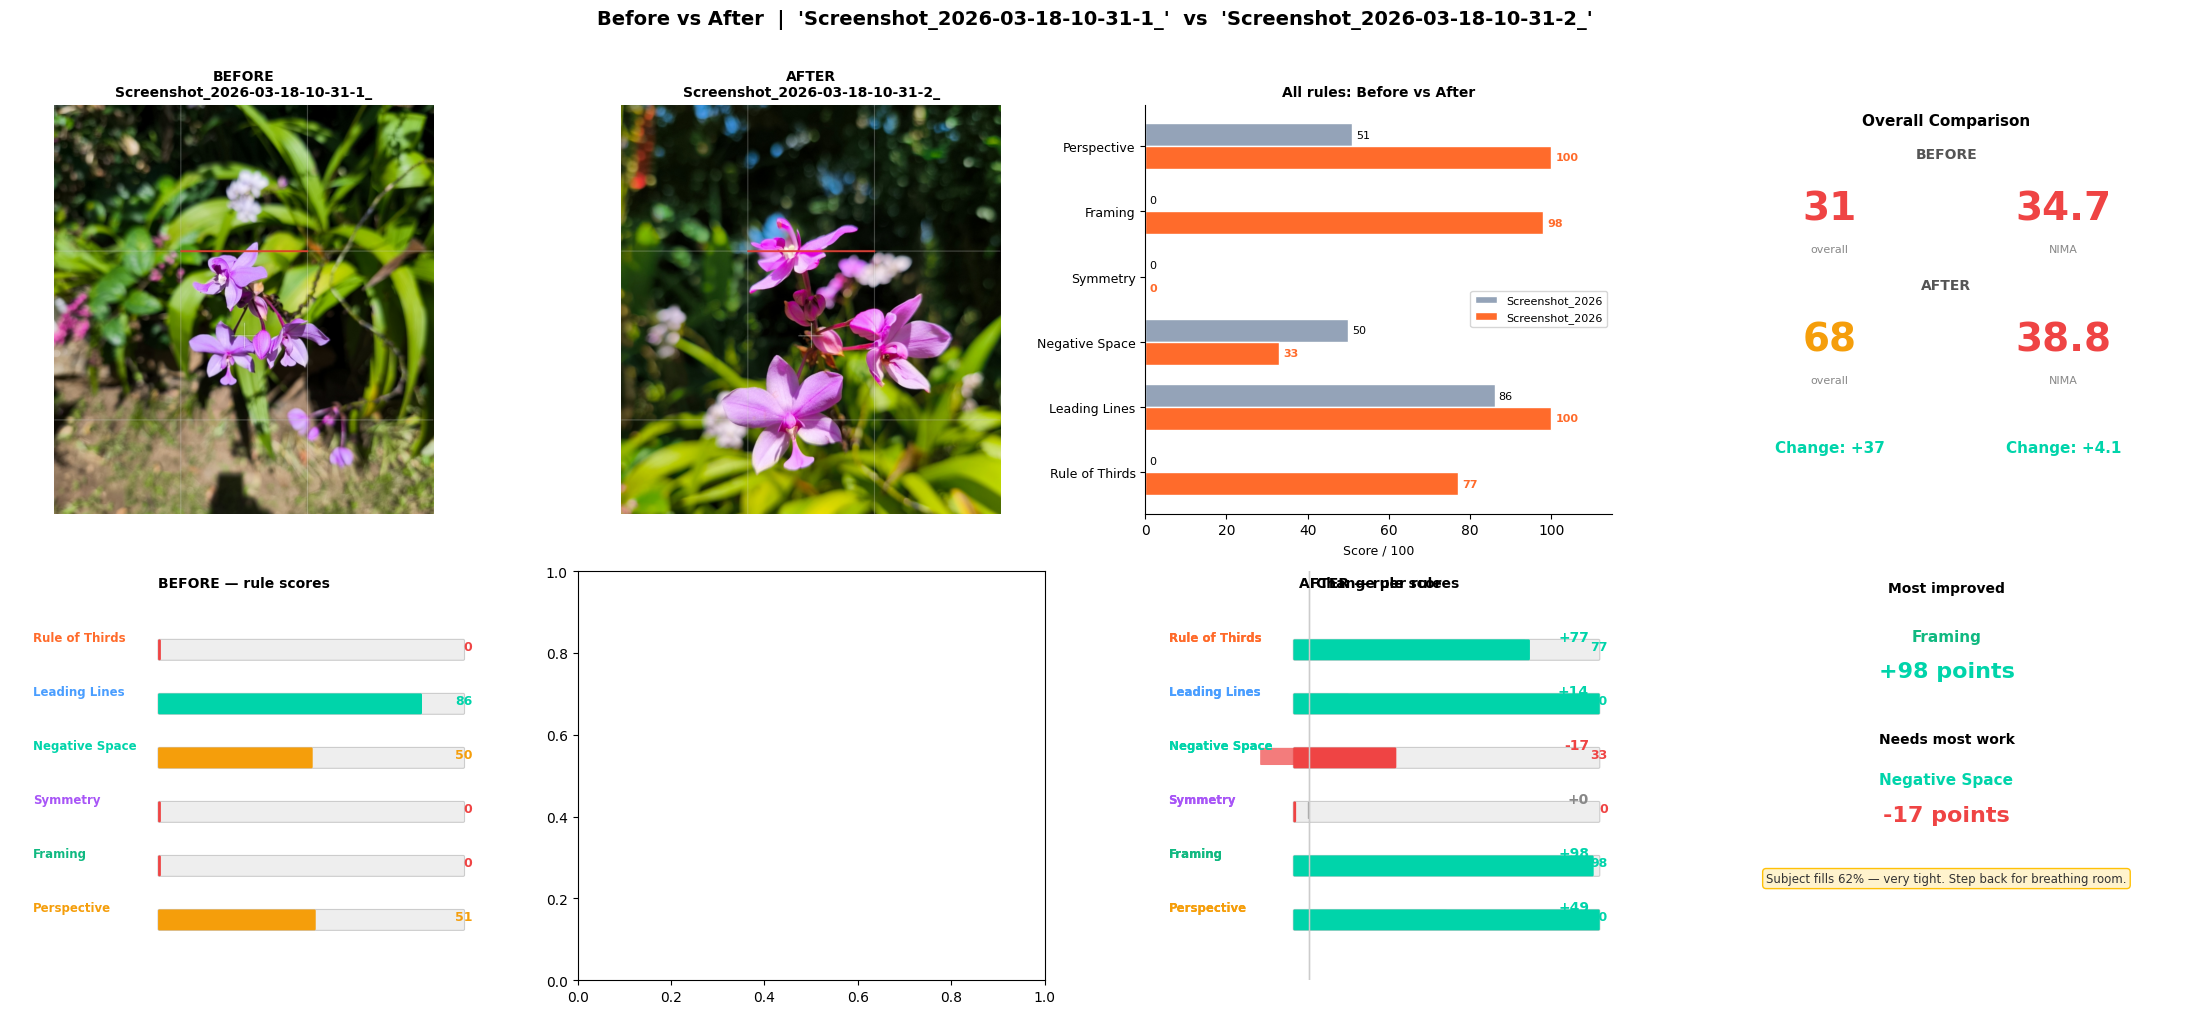


Rule                 Before    After   Change
──────────────────────────────────────────────────────────────────────
  Rule of Thirds          0       77     +77  ↑
  Leading Lines          86      100     +14  ↑
  Negative Space         50       33     -17  ↓
  Symmetry                0        0       0  →
  Framing                 0       98     +98  ↑
  Perspective            51      100     +49  ↑
──────────────────────────────────────────────────────────────────────
  Overall                31       68 +     37
  NIMA                 34.7     38.8 +    4.1


In [46]:
# ── CELL 8: Before / After side-by-side comparison ────────────
# Only runs if you uploaded exactly 2 photos

if len(results) == 2:
    A, B   = results[0], results[1]
    rnames = list(A['rules'].keys())

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(
        f"Before vs After  |  "
        f"'{A['label']}'  vs  '{B['label']}'",
        fontsize=14, fontweight='bold', y=1.01)

    # Row 0: photos side by side
    axes[0,0].imshow(A['image'])
    axes[0,0].set_title(f"BEFORE\n{A['label']}",
                        fontsize=10, fontweight='bold')
    axes[0,0].axis('off')

    axes[0,1].imshow(B['image'])
    axes[0,1].set_title(f"AFTER\n{B['label']}",
                        fontsize=10, fontweight='bold')
    axes[0,1].axis('off')

    # Row 0 col 2: side-by-side bar chart of all rules
    ax_bars = axes[0, 2]
    y_pos   = np.arange(len(rnames))
    bar_h   = 0.35

    barsA = ax_bars.barh(y_pos + bar_h/2,
                          [A['rules'][r][0] for r in rnames],
                          height=bar_h, label=A['label'][:15],
                          color='#94A3B8', edgecolor='white')
    barsB = ax_bars.barh(y_pos - bar_h/2,
                          [B['rules'][r][0] for r in rnames],
                          height=bar_h, label=B['label'][:15],
                          color='#FF6B2B', edgecolor='white')

    for bar in barsA:
        v = bar.get_width()
        ax_bars.text(v+1, bar.get_y()+bar.get_height()/2,
                     f'{int(v)}', va='center', fontsize=8)
    for bar in barsB:
        v = bar.get_width()
        ax_bars.text(v+1, bar.get_y()+bar.get_height()/2,
                     f'{int(v)}', va='center', fontsize=8,
                     color='#FF6B2B', fontweight='bold')

    ax_bars.set_yticks(y_pos)
    ax_bars.set_yticklabels(rnames, fontsize=9)
    ax_bars.set_xlim(0, 115)
    ax_bars.set_xlabel("Score / 100", fontsize=9)
    ax_bars.set_title("All rules: Before vs After",
                      fontsize=10, fontweight='bold')
    ax_bars.legend(fontsize=8)
    ax_bars.spines[['top','right']].set_visible(False)

    # Row 0 col 3: overall + NIMA comparison
    ax_ov = axes[0, 3]
    ax_ov.set_xlim(0,10); ax_ov.set_ylim(0,10); ax_ov.axis('off')
    ax_ov.text(5, 9.5, "Overall Comparison",
               ha='center', fontsize=11, fontweight='bold')

    for row_y, lbl, ov, ni in [
        (7.2, "BEFORE", A['overall'], A['nima']),
        (4.0, "AFTER",  B['overall'], B['nima']),
    ]:
        oc = score_color(ov)
        nc = score_color(ni)
        ax_ov.text(5, row_y+1.5, lbl,
                   ha='center', fontsize=10, fontweight='bold',
                   color='#555')
        ax_ov.text(2.5, row_y, str(ov),
                   ha='center', fontsize=28,
                   fontweight='bold', color=oc)
        ax_ov.text(2.5, row_y-0.8, "overall",
                   ha='center', fontsize=8, color='#888')
        ax_ov.text(7.5, row_y, str(ni),
                   ha='center', fontsize=28,
                   fontweight='bold', color=nc)
        ax_ov.text(7.5, row_y-0.8, "NIMA",
                   ha='center', fontsize=8, color='#888')

    diff_ov = B['overall'] - A['overall']
    diff_ni = B['nima']    - A['nima']
    sym = lambda d: f"+{d}" if d > 0 else str(d)
    c_ov = "#00D4AA" if diff_ov >= 0 else "#EF4444"
    c_ni = "#00D4AA" if diff_ni >= 0 else "#EF4444"
    ax_ov.text(2.5, 1.5,
               f"Change: {sym(diff_ov)}",
               ha='center', fontsize=11,
               fontweight='bold', color=c_ov)
    ax_ov.text(7.5, 1.5,
               f"Change: {sym(round(diff_ni,1))}",
               ha='center', fontsize=11,
               fontweight='bold', color=c_ni)

    # Row 1: per-rule score cards for each
    for col, res in enumerate([A, B]):
        ax = axes[1, col*2]
        ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
        prefix = "BEFORE" if col == 0 else "AFTER"
        ax.text(5, 9.6, f"{prefix} — rule scores",
                ha='center', fontsize=10, fontweight='bold')
        for i, rn in enumerate(rnames):
            rs  = res['rules'][rn][0]
            sc  = score_color(rs)
            rc  = RULE_COLORS.get(rn, '#888')
            y   = 8.3 - i * 1.32
            ax.text(0.5, y, rn, fontsize=8.5,
                    color=rc, fontweight='bold')
            draw_score_bar(ax, y-0.45, rs,
                           sc, width=6.5, x=3.2)
            ax.text(9.9, y-0.22, str(rs),
                    fontsize=9, fontweight='bold',
                    color=sc, ha='right')

    # Improvement breakdown
    ax_imp = axes[1, 2]
    ax_imp.set_xlim(0,10); ax_imp.set_ylim(0,10); ax_imp.axis('off')
    ax_imp.text(5, 9.6, "Change per rule",
                ha='center', fontsize=10, fontweight='bold')
    for i, rn in enumerate(rnames):
        sa  = A['rules'][rn][0]
        sb  = B['rules'][rn][0]
        diff = sb - sa
        col  = "#00D4AA" if diff > 5  else \
               "#EF4444" if diff < -5 else "#888888"
        rc   = RULE_COLORS.get(rn, '#888')
        y    = 8.3 - i * 1.32
        ax_imp.text(0.5, y, rn,
                    fontsize=8.5, color=rc, fontweight='bold')
        ax_imp.text(9.5, y,
                    f"{'+' if diff>=0 else ''}{diff}",
                    fontsize=10, fontweight='bold',
                    color=col, ha='right')
        # Mini bar
        bw = abs(diff) / 100 * 6
        bx = 3.5 if diff >= 0 else 3.5 - bw
        b  = mpatches.FancyBboxPatch(
            (bx, y-0.38), bw, 0.38,
            boxstyle="round,pad=0.02",
            facecolor=col, edgecolor='none', alpha=0.7)
        ax_imp.add_patch(b)
        ax_imp.axvline(3.5, color='#ccc', lw=0.8,
                       ymin=0, ymax=1)

    # Most improved rule
    ax_best = axes[1, 3]
    ax_best.set_xlim(0,10); ax_best.set_ylim(0,10); ax_best.axis('off')
    diffs    = {rn: B['rules'][rn][0]-A['rules'][rn][0]
                for rn in rnames}
    best_rn  = max(diffs, key=diffs.get)
    worst_rn = min(diffs, key=diffs.get)

    ax_best.text(5, 9.5, "Most improved",
                 ha='center', fontsize=10, fontweight='bold')
    ax_best.text(5, 8.3, best_rn,
                 ha='center', fontsize=11,
                 color=RULE_COLORS.get(best_rn,'#888'),
                 fontweight='bold')
    ax_best.text(5, 7.4,
                 f"+{diffs[best_rn]} points",
                 ha='center', fontsize=16,
                 color='#00D4AA', fontweight='bold')
    ax_best.text(5, 5.8, "Needs most work",
                 ha='center', fontsize=10, fontweight='bold')
    ax_best.text(5, 4.8, worst_rn,
                 ha='center', fontsize=11,
                 color=RULE_COLORS.get(worst_rn,'#888'),
                 fontweight='bold')
    ax_best.text(5, 3.9,
                 f"{diffs[worst_rn]:+d} points",
                 ha='center', fontsize=16,
                 color='#EF4444', fontweight='bold')
    ax_best.text(5, 2.4, B['rules'][worst_rn][1],
                 ha='center', fontsize=8.5, color='#333',
                 multialignment='center',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#fff3cd',
                           edgecolor='#ffc107', lw=1))

    plt.tight_layout()
    plt.show()

    # ── Clean printed comparison table ───────────────────────
    print("\n" + "="*70)
    print(f"{'Rule':<18} {'Before':>8} {'After':>8} {'Change':>8}")
    print("─"*70)
    for rn in rnames:
        sa   = A['rules'][rn][0]
        sb   = B['rules'][rn][0]
        diff = sb - sa
        sym  = f"+{diff}" if diff > 0 else str(diff)
        flag = "↑" if diff > 5 else "↓" if diff < -5 else "→"
        print(f"  {rn:<16} {sa:>8} {sb:>8} {sym:>7}  {flag}")
    print("─"*70)
    print(f"  {'Overall':<16} {A['overall']:>8} "
          f"{B['overall']:>8} "
          f"{'+' if B['overall']>=A['overall'] else ''}"
          f"{B['overall']-A['overall']:>7}")
    print(f"  {'NIMA':<16} {A['nima']:>8} "
          f"{B['nima']:>8} "
          f"{'+' if B['nima']>=A['nima'] else ''}"
          f"{round(B['nima']-A['nima'],1):>7}")
    print("="*70)

elif len(results) == 1:
    print("\nOnly 1 photo analysed — upload 2 photos to see before/after comparison.")
else:
    print(f"\n{len(results)} photos analysed.")
    print("Upload exactly 2 photos for before/after comparison.")

In [ ]:
# ── CELL 9: Save all models to Google Drive ───────────────────
from google.colab import drive
import shutil

drive.mount('/content/drive')
folder = '/content/drive/MyDrive/FrameAI_models'
os.makedirs(folder, exist_ok=True)

for fname in ['deeplabv3.tflite',
              'midas_small.tflite',
              'nima_mobilenet.tflite']:
    if os.path.exists(fname):
        shutil.copy(fname, f"{folder}/{fname}")
        print(f"Saved: {fname}")

# Save YOLOv8n weights too
if os.path.exists("yolov8n.pt"):
    shutil.copy("yolov8n.pt", f"{folder}/yolov8n.pt")
    print("Saved: yolov8n.pt")

print(f"\nAll models saved to {folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: deeplabv3.tflite
Saved: midas_small.tflite
Saved: nima_mobilenet.tflite
Saved: yolov8n.pt

All models saved to /content/drive/MyDrive/FrameAI_models


In [ ]:
# Connect Google Drive to Colab
# A popup will appear asking you to sign in — click Allow

from google.colab import drive
drive.mount('/content/drive')
print("Google Drive connected successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully.


In [ ]:
# Before uploading, confirm all 4 files exist in your Drive
import os

DRIVE_FOLDER = "/content/drive/MyDrive/FrameAI_models"

files_needed = [
    "yolov8n_int8.tflite",
    "deeplabv3.tflite",
    "midas_small.tflite",
    "nima_mobilenet.tflite",
]

print(f"Looking in: {DRIVE_FOLDER}")
print()

if not os.path.exists(DRIVE_FOLDER):
    print("ERROR — FrameAI_models folder not found in your Drive.")
    print("Make sure the folder name is exactly:  FrameAI_models")
    print("(capital F, capital A, capital M — no spaces)")
else:
    all_ready = True
    for fname in files_needed:
        full_path = os.path.join(DRIVE_FOLDER, fname)
        if os.path.exists(full_path):
            size_mb = os.path.getsize(full_path) / 1024 / 1024
            print(f"  FOUND     {fname}  ({size_mb:.1f} MB)")
        else:
            print(f"  MISSING   {fname}")
            all_ready = False

    print()
    if all_ready:
        print("All 4 files found. Ready to upload to GitHub.")
    else:
        print("Some files are missing.")
        print("Go back and save those models to Drive first.")

Looking in: /content/drive/MyDrive/FrameAI_models

  MISSING   yolov8n_int8.tflite
  FOUND     deeplabv3.tflite  (2.7 MB)
  FOUND     midas_small.tflite  (63.3 MB)
  FOUND     nima_mobilenet.tflite  (3.2 MB)

Some files are missing.
Go back and save those models to Drive first.


In [ ]:
# ── Install Ultralytics ───────────────────────────────────────
!pip install ultralytics -q
print("Ultralytics installed.")

Ultralytics installed.


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Check the .pt file is there
pt_path = "/content/drive/MyDrive/FrameAI_models/yolov8n.pt"

if os.path.exists(pt_path):
    mb = os.path.getsize(pt_path) / 1024 / 1024
    print(f"Found yolov8n.pt  ({mb:.1f} MB)")
else:
    print("yolov8n.pt not found at expected path.")
    print("Searching your Drive for it...")

    # Search everywhere in Drive
    for root, dirs, files in os.walk("/content/drive/MyDrive"):
        for fname in files:
            if fname == "yolov8n.pt":
                full = os.path.join(root, fname)
                mb   = os.path.getsize(full) / 1024 / 1024
                print(f"Found at: {full}  ({mb:.1f} MB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found yolov8n.pt  (6.2 MB)


In [ ]:
import shutil, os
from ultralytics import YOLO

# ── Copy from Drive to Colab local storage ────────────────────
# Conversion works faster from local storage than Drive
pt_drive = "/content/drive/MyDrive/FrameAI_models/yolov8n.pt"
pt_local = "/content/yolov8n.pt"

print("Copying yolov8n.pt from Drive to Colab...")
shutil.copy(pt_drive, pt_local)
print(f"Copied. Size: {os.path.getsize(pt_local)/1024/1024:.1f} MB")

# ── Load the model ────────────────────────────────────────────
print("\nLoading YOLOv8n model...")
model = YOLO(pt_local)
print("Model loaded.")

# ── Export to TFLite ──────────────────────────────────────────
# int8 = quantized version — smaller file, faster on Android
# imgsz=320 = input image size (320x320 is good for phones)
print("\nConverting to TFLite (int8 quantized)...")
print("This takes about 2-3 minutes...")

model.export(
    format = 'tflite',
    imgsz  = 320,
    int8   = True,
)

print("\nConversion complete.")

Copying yolov8n.pt from Drive to Colab...
Copied. Size: 6.2 MB

Loading YOLOv8n model...
Model loaded.

Converting to TFLite (int8 quantized)...
This takes about 2-3 minutes...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from '/content/yolov8n.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 84, 2100) (6.2 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Re

In [ ]:
import os, glob

# Ultralytics saves the tflite inside a folder called
# yolov8n_saved_model/
print("Searching for the exported .tflite file...\n")

# Search common locations
search_patterns = [
    "/content/yolov8n_saved_model/*.tflite",
    "/content/yolov8n_saved_model/**/*.tflite",
    "/content/*.tflite",
]

found_files = []
for pattern in search_patterns:
    matches = glob.glob(pattern, recursive=True)
    found_files.extend(matches)

if found_files:
    print(f"Found {len(found_files)} .tflite file(s):\n")
    for f in found_files:
        mb = os.path.getsize(f) / 1024 / 1024
        print(f"  {f}")
        print(f"  Size: {mb:.1f} MB")
        print()
else:
    print("No .tflite file found yet.")
    print("Try listing the folder manually:")
    print("  !ls -la /content/yolov8n_saved_model/")

Searching for the exported .tflite file...

Found 13 .tflite file(s):

  /content/yolov8n_saved_model/yolov8n_full_integer_quant.tflite
  Size: 3.2 MB

  /content/yolov8n_saved_model/yolov8n_float16.tflite
  Size: 6.1 MB

  /content/yolov8n_saved_model/yolov8n_int8.tflite
  Size: 3.2 MB

  /content/yolov8n_saved_model/yolov8n_integer_quant.tflite
  Size: 3.2 MB

  /content/yolov8n_saved_model/yolov8n_float32.tflite
  Size: 12.1 MB

  /content/yolov8n_saved_model/yolov8n_full_integer_quant.tflite
  Size: 3.2 MB

  /content/yolov8n_saved_model/yolov8n_float16.tflite
  Size: 6.1 MB

  /content/yolov8n_saved_model/yolov8n_int8.tflite
  Size: 3.2 MB

  /content/yolov8n_saved_model/yolov8n_integer_quant.tflite
  Size: 3.2 MB

  /content/yolov8n_saved_model/yolov8n_float32.tflite
  Size: 12.1 MB

  /content/nima_mobilenet.tflite
  Size: 3.2 MB

  /content/midas_small.tflite
  Size: 63.3 MB

  /content/deeplabv3.tflite
  Size: 2.7 MB



In [ ]:
import shutil, os, glob

# Find the tflite file (it might be named slightly differently)
tflite_files = glob.glob(
    "/content/yolov8n_saved_model/*.tflite",
    recursive=True
)

if not tflite_files:
    # Try broader search
    tflite_files = glob.glob("/content/**/*.tflite", recursive=True)

if not tflite_files:
    print("ERROR: No .tflite file found.")
    print("Check Cell 3 ran without errors.")
else:
    # Use the first (and usually only) tflite file found
    source_file = tflite_files[0]
    mb          = os.path.getsize(source_file) / 1024 / 1024

    print(f"Source file : {source_file}")
    print(f"Size        : {mb:.1f} MB\n")

    # Save to Drive with the correct name
    dest = "/content/drive/MyDrive/FrameAI_models/yolov8n_int8.tflite"
    shutil.copy(source_file, dest)

    # Verify
    if os.path.exists(dest):
        saved_mb = os.path.getsize(dest) / 1024 / 1024
        print(f"Saved to Drive: {dest}")
        print(f"Size          : {saved_mb:.1f} MB")
        print("\nyolov8n_int8.tflite is now in your Drive.")
        print("You can now re-run the GitHub upload cell.")
    else:
        print("ERROR: File did not save to Drive correctly.")

Source file : /content/yolov8n_saved_model/yolov8n_full_integer_quant.tflite
Size        : 3.2 MB

Saved to Drive: /content/drive/MyDrive/FrameAI_models/yolov8n_int8.tflite
Size          : 3.2 MB

yolov8n_int8.tflite is now in your Drive.
You can now re-run the GitHub upload cell.


In [ ]:
import os

DRIVE_FOLDER = "/content/drive/MyDrive/FrameAI_models"

files_needed = [
    "yolov8n_int8.tflite",
    "deeplabv3.tflite",
    "midas_small.tflite",
    "nima_mobilenet.tflite",
]

print(f"Checking: {DRIVE_FOLDER}\n")

all_ready = True
for fname in files_needed:
    full_path = os.path.join(DRIVE_FOLDER, fname)
    if os.path.exists(full_path):
        mb = os.path.getsize(full_path) / 1024 / 1024
        print(f"  FOUND    {fname:<30}  {mb:.1f} MB")
    else:
        print(f"  MISSING  {fname}")
        all_ready = False

print()
if all_ready:
    print("All 4 files ready.")
    print("Go back and run the GitHub upload cell now.")
else:
    print("Some files still missing — check the cells above.")

Checking: /content/drive/MyDrive/FrameAI_models

  FOUND    yolov8n_int8.tflite             3.2 MB
  FOUND    deeplabv3.tflite                2.7 MB
  FOUND    midas_small.tflite              63.3 MB
  FOUND    nima_mobilenet.tflite           3.2 MB

All 4 files ready.
Go back and run the GitHub upload cell now.


In [ ]:
# Before uploading, confirm all 4 files exist in your Drive
import os

DRIVE_FOLDER = "/content/drive/MyDrive/FrameAI_models"

files_needed = [
    "yolov8n_int8.tflite",
    "deeplabv3.tflite",
    "midas_small.tflite",
    "nima_mobilenet.tflite",
]

print(f"Looking in: {DRIVE_FOLDER}")
print()

if not os.path.exists(DRIVE_FOLDER):
    print("ERROR — FrameAI_models folder not found in your Drive.")
    print("Make sure the folder name is exactly:  FrameAI_models")
    print("(capital F, capital A, capital M — no spaces)")
else:
    all_ready = True
    for fname in files_needed:
        full_path = os.path.join(DRIVE_FOLDER, fname)
        if os.path.exists(full_path):
            size_mb = os.path.getsize(full_path) / 1024 / 1024
            print(f"  FOUND     {fname}  ({size_mb:.1f} MB)")
        else:
            print(f"  MISSING   {fname}")
            all_ready = False

    print()
    if all_ready:
        print("All 4 files found. Ready to upload to GitHub.")
    else:
        print("Some files are missing.")
        print("Go back and save those models to Drive first.")

Looking in: /content/drive/MyDrive/FrameAI_models

  FOUND     yolov8n_int8.tflite  (3.2 MB)
  FOUND     deeplabv3.tflite  (2.7 MB)
  FOUND     midas_small.tflite  (63.3 MB)
  FOUND     nima_mobilenet.tflite  (3.2 MB)

All 4 files found. Ready to upload to GitHub.


In [49]:
# ══════════════════════════════════════════════
# FILL IN THESE 3 VALUES BEFORE RUNNING
# ══════════════════════════════════════════════

# Your GitHub username — the name you see at github.com/YOUR_NAME
GITHUB_USERNAME = "SahanWijayaraja"

# Your repository name — should be exactly: frameai
GITHUB_REPO = "Frame-AI"

# The token you just created — starts with ghp_
GITHUB_TOKEN = "YOUR_TOKEN_REMOVED_FOR_PRIVACY"

# The folder path inside your repo where models go
GITHUB_DEST  = "Frame-AI_app/assets/models"

# ══════════════════════════════════════════════

# Quick check — make sure you actually filled them in
errors = []
if GITHUB_USERNAME == "your_username_here":
    errors.append("GITHUB_USERNAME is still the example value")
if GITHUB_TOKEN == "ghp_paste_your_token_here" or GITHUB_TOKEN == "YOUR_TOKEN_REMOVED_FOR_PRIVACY":
    errors.append("GITHUB_TOKEN is still the example value or has been removed")
if not GITHUB_TOKEN.startswith("ghp_") and GITHUB_TOKEN != "YOUR_TOKEN_REMOVED_FOR_PRIVACY":
    errors.append("GITHUB_TOKEN does not start with ghp_ — check you copied it correctly")

if errors:
    for e in errors:
        print(f"  FIX NEEDED:  {e}")
else:
    print("Settings look correct.")
    print(f"  Username  :  {GITHUB_USERNAME}")
    print(f"  Repo      :  {GITHUB_REPO}")
    print(f"  Token     :  {GITHUB_TOKEN[:8]}{'*' * 20}")
    print(f"  Dest path :  {GITHUB_DEST}")

  FIX NEEDED:  GITHUB_TOKEN is still the example value or has been removed


In [ ]:
import requests
import base64
import os
import time

def upload_one_file(local_path, repo_path, username,
                    repo, token):
    """
    Reads one file from local disk and uploads it to GitHub.
    Handles both creating new files and updating existing ones.
    """
    filename = os.path.basename(local_path)

    # Step A — Read the file bytes and convert to base64
    # GitHub API requires base64 encoding for all file content
    with open(local_path, "rb") as f:
        file_bytes = f.read()
    encoded = base64.b64encode(file_bytes).decode("utf-8")
    size_mb = len(file_bytes) / 1024 / 1024

    print(f"  File size  : {size_mb:.1f} MB")
    print(f"  Encoded    : {len(encoded):,} characters")

    # Step B — Build the GitHub API URL for this file
    api_url = (f"https://api.github.com/repos/"
               f"{username}/{repo}/contents/{repo_path}")

    headers = {
        "Authorization" : f"token {token}",
        "Accept"        : "application/vnd.github.v3+json",
        "User-Agent"    : "FrameAI-Uploader"
    }

    # Step C — Check if the file already exists in the repo
    # If it exists, GitHub needs the current file's SHA to update it
    print(f"  Checking if file already exists in repo...")
    check_response = requests.get(api_url, headers=headers)

    sha = None
    if check_response.status_code == 200:
        sha = check_response.json().get("sha")
        print(f"  File exists — will overwrite it")
    elif check_response.status_code == 404:
        print(f"  File does not exist yet — will create it")
    elif check_response.status_code == 401:
        print("  ERROR: Token rejected. Check your token is correct.")
        return False
    elif check_response.status_code == 403:
        print("  ERROR: Token does not have repo permission.")
        print("  Go back and create a new token with the 'repo' scope ticked.")
        return False

    # Step D — Build the request body
    request_body = {
        "message" : f"Add {filename} — FrameAI model file",
        "content" : encoded,
    }
    # If file exists, include its SHA so GitHub knows what to replace
    if sha:
        request_body["sha"] = sha

    # Step E — Send the upload request
    print(f"  Uploading... (please wait)")
    upload_response = requests.put(
        api_url,
        headers=headers,
        json=request_body
    )

    # Step F — Check if it worked
    if upload_response.status_code in (200, 201):
        action   = "Updated" if upload_response.status_code == 200 \
                   else "Created"
        file_url = (upload_response.json()
                    .get("content", {})
                    .get("html_url", ""))
        print(f"  SUCCESS — {action}")
        print(f"  View at : {file_url}")
        return True

    else:
        print(f"  FAILED — status code: {upload_response.status_code}")
        try:
            error_msg = upload_response.json().get("message", "unknown error")
            print(f"  Reason  : {error_msg}")

            if "too large" in error_msg.lower():
                print()
                print("  This file is too large for the GitHub API.")
                print("  Use the Git terminal method in Cell 5 instead.")

            elif "Bad credentials" in error_msg:
                print()
                print("  Your token is wrong or expired.")
                print("  Go to GitHub and create a new token.")

            elif "not found" in error_msg.lower():
                print()
                print("  Repository not found.")
                print(f"  Check that '{repo}' exists at")
                print(f"  github.com/{username}/{repo}")

        except Exception:
            print(f"  Raw: {upload_response.text[:300]}")
        return False


# ── Upload all 4 files one by one ─────────────────────────────
print("=" * 60)
print("UPLOADING MODEL FILES TO GITHUB")
print(f"  From : Google Drive/FrameAI_models/")
print(f"  To   : github.com/{GITHUB_USERNAME}/{GITHUB_REPO}")
print(f"         /{GITHUB_DEST}/")
print("=" * 60)

upload_results = {}

files_to_upload = [
    "yolov8n_int8.tflite",
    "deeplabv3.tflite",
    "midas_small.tflite",
    "nima_mobilenet.tflite",
]

for filename in files_to_upload:
    print(f"\n{'─' * 55}")
    print(f"Uploading: {filename}")

    local  = os.path.join(DRIVE_FOLDER, filename)
    remote = f"{GITHUB_DEST}/{filename}"

    if not os.path.exists(local):
        print(f"  SKIPPED — not found in Drive")
        upload_results[filename] = "missing"
        continue

    success = upload_one_file(
        local_path = local,
        repo_path  = remote,
        username   = GITHUB_USERNAME,
        repo       = GITHUB_REPO,
        token      = GITHUB_TOKEN,
    )

    upload_results[filename] = "ok" if success else "failed"

    if success:
        # Small pause so GitHub does not rate-limit us
        print(f"  Waiting 3 seconds before next file...")
        time.sleep(3)

# ── Print final results table ─────────────────────────────────
print(f"\n{'=' * 60}")
print("FINAL RESULTS")
print("=" * 60)

all_ok = True
for fname, status in upload_results.items():
    if status == "ok":
        icon = "✓"
    elif status == "failed":
        icon = "✗"
        all_ok = False
    else:
        icon = "—"
        all_ok = False
    print(f"  {icon}  {fname:<35}  {status.upper()}")

print()
if all_ok:
    print("All 4 files uploaded successfully.")
    print()
    print("Check your GitHub repo at:")
    print(f"  https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}"
          f"/tree/main/{GITHUB_DEST}")
    print()
    print("You should see all 4 .tflite files listed there.")
    print("You are now ready for Phase 4 — adding the app code.")
else:
    failed = [k for k, v in upload_results.items()
              if v != "ok"]
    print(f"These files need attention: {failed}")
    print("Run Cell 5 below for an alternative method.")

UPLOADING MODEL FILES TO GITHUB
  From : Google Drive/FrameAI_models/
  To   : github.com/SahanWijayaraja/Frame-AI
         /Frame-AI_app/assets/models/

───────────────────────────────────────────────────────
Uploading: yolov8n_int8.tflite
  File size  : 3.2 MB
  Encoded    : 4,518,060 characters
  Checking if file already exists in repo...
  File does not exist yet — will create it
  Uploading... (please wait)
  SUCCESS — Created
  View at : https://github.com/SahanWijayaraja/Frame-AI/blob/main/Frame-AI_app/assets/models/yolov8n_int8.tflite
  Waiting 3 seconds before next file...

───────────────────────────────────────────────────────
Uploading: deeplabv3.tflite
  File size  : 2.7 MB
  Encoded    : 3,705,688 characters
  Checking if file already exists in repo...
  File does not exist yet — will create it
  Uploading... (please wait)
  SUCCESS — Created
  View at : https://github.com/SahanWijayaraja/Frame-AI/blob/main/Frame-AI_app/assets/models/deeplabv3.tflite
  Waiting 3 seconds b

In [48]:
!git config --global --unset credential.helper
!rm -rf ~/.git-credentials